# Machine Learning for Short-Term Market Direction Prediction

## Predicting Positive Market Moves Using Gradient Boosting

This notebook develops a supervised machine learning framework to predict short-term positive market moves for SPY, the SPDR S&P 500 ETF Trust. The task is formulated as a binary classification problem, where the dependent variable is labelled as 1 for an uptrend and 0 otherwise.

The workflow follows a structured machine learning process:

1. Ideation  
2. Data Collection  
3. Initial Exploratory Data Analysis  
4. Data Cleaning  
5. Feature Engineering and Transformation  
6. Modeling  
7. Evaluation  

The final model will be based on Gradient Boosting methods, with feature selection performed through a funnel-style approach combining filter, wrapper, and embedded methods.

## Executive Summary

This report develops a supervised machine learning framework to predict positive short-term market moves for SPY, the SPDR S&P 500 ETF Trust. The task is formulated as a binary classification problem, where the dependent variable is labelled as 1 if the next trading day's log return exceeds a near-zero threshold of 0.05%, and 0 otherwise.

The study follows a complete machine learning workflow, including data collection, exploratory data analysis, data cleaning, feature engineering, funnel-style feature selection, Gradient Boosting model tuning, and out-of-sample evaluation.

A broad set of 83 candidate features is constructed from daily OHLCV data. These features include lagged returns, rolling returns, volatility measures, moving average relationships, volume dynamics, and technical indicators. A funnel-style feature selection process combining filter, wrapper, and embedded methods reduces the feature set from 83 to 17 final predictors.

The tuned Gradient Boosting classifier achieves a test ROC-AUC of 0.5064, which is only marginally above random classification. The confusion matrix and classification report show that the model tends to predict the positive class more frequently, resulting in relatively high recall for up days but weak performance in identifying non-positive days. The optional signal-based backtest does not outperform a buy-and-hold benchmark.

Overall, the empirical results confirm that short-term equity market direction is difficult to predict. The implemented workflow is complete and methodologically valid, but the selected technical features provide limited out-of-sample predictive power for SPY over the test period.

# Step 1: Ideation

## 1.1 Research Objective

The objective of this study is to build a machine learning model that predicts whether SPY will experience a positive short-term market move. The prediction target is the next trading day's market direction, represented as a binary classification label.

The selected asset is SPY, which is widely used as a liquid proxy for the U.S. equity market. SPY is suitable for this exercise because it has deep liquidity, long historical data availability, and strong relevance to broad market forecasting.

## 1.2 Prediction Task

The task is defined as a supervised binary classification problem.

Let $r_{t+1}$ denote the next trading day's log return of SPY. The dependent variable is defined as:

$$
Y_t =
\begin{cases}
1, & \text{if } r_{t+1} > \tau \\
0, & \text{otherwise}
\end{cases}
$$

where $\tau$ is a near-zero return threshold. The threshold is used to avoid treating very small noisy returns as meaningful positive moves.

The initial threshold is set to 0.05% and may be reviewed after examining the empirical distribution of SPY daily returns.

## 1.3 Asset Selection

The selected ticker is:

- Ticker: SPY
- Asset type: Exchange-Traded Fund
- Underlying exposure: S&P 500 Index
- Data frequency: Daily
- Planned sample period: 2020-01-01 to 2025-12-31

SPY is chosen because the exam focuses on short-term asset return prediction, and SPY provides a clean, liquid, and representative market instrument. Its daily OHLCV data can be used to construct a sufficiently large set of technical, return-based, volatility-based, and volume-based features.

## 1.4 Modeling Strategy

The modeling framework will be developed in three main stages.

First, a broad feature set will be engineered from daily OHLCV data. Candidate features will include lagged returns, rolling returns, rolling volatility, moving average relationships, price range indicators, volume dynamics, and technical indicators.

Second, a funnel-style feature selection process will be applied. This process will combine:

- Filter methods, such as correlation screening, variance filtering, and univariate statistical scores;
- Wrapper methods, such as recursive feature elimination;
- Embedded methods, such as tree-based feature importance or regularized models.

Third, the selected feature subset will be used to train and tune a Gradient Boosting classifier. Hyperparameters will be selected using a validation or cross-validation framework that respects the time-series structure of the data.

## 1.5 Evaluation Criteria

The model will be evaluated using classification metrics required for the exam and additional supporting metrics.

The primary evaluation metrics are:

- ROC-AUC
- Confusion matrix
- Classification report, including precision, recall, and F1-score

Additional supporting metrics may include:

- Accuracy
- Balanced accuracy
- Feature importance analysis
- Optional signal-based backtest

ROC-AUC is used as a primary metric because it evaluates the model's ability to rank positive observations above negative observations across different classification thresholds. The confusion matrix and classification report provide a more detailed view of classification errors and class-specific performance.

## 1.6 Data Leakage Controls

Since the task involves financial time-series prediction, the implementation must avoid data leakage.

The main controls are:

1. Features at time $t$ must only use information available at or before time $t$.
2. The label is based on the next trading day's return, $r_{t+1}$, and must not be used in feature construction.
3. Train-test splitting must preserve chronological order.
4. Scaling, imputation, feature selection, and model tuning should be fitted only on the training data or within a proper validation framework.
5. The final test set should be used only for out-of-sample evaluation.

These controls are essential because leakage can produce over-optimistic backtest and classification results that would not be achievable in real-time prediction.

In [ ]:
# =========================
# Step 1: Project configuration
# =========================

TICKER = "SPY"

START_DATE = "2020-01-01"
END_DATE = "2026-01-01"

FORECAST_HORIZON = 1

# Initial near-zero return threshold for defining positive market moves.
# This threshold may be reviewed after the return distribution is examined.
NEAR_ZERO_THRESHOLD = 0.0005

# Train-test split ratio based on chronological ordering.
TRAIN_RATIO = 0.8

print("Project configuration")
print("---------------------")
print(f"Ticker: {TICKER}")
print(f"Sample period: {START_DATE} to {END_DATE}")
print(f"Forecast horizon: {FORECAST_HORIZON} trading day")
print(f"Initial near-zero threshold: {NEAR_ZERO_THRESHOLD:.4%}")
print(f"Training sample ratio: {TRAIN_RATIO:.0%}")

Project configuration
---------------------
Ticker: SPY
Sample period: 2020-01-01 to 2026-01-01
Forecast horizon: 1 trading day
Initial near-zero threshold: 0.0500%
Training sample ratio: 80%


# Step 2: Data Collection

## 2.1 Data Source

Daily OHLCV data for SPY are collected from Yahoo Finance using the `yfinance` Python package. SPY is selected as a liquid proxy for the U.S. equity market and provides sufficient historical data for short-term return prediction.

The raw dataset contains the following fields:

- Date
- Open
- High
- Low
- Close
- Adjusted Close
- Volume

The adjusted closing price will be used later to compute log returns and construct the binary target variable. At this stage, the objective is only to collect and store the raw market data in a reproducible format.

In [ ]:
# =========================
# Step 2: Install and import packages
# =========================

!pip install -q yfinance

import os
import pandas as pd
import numpy as np
import yfinance as yf

In [ ]:
# =========================
# Step 2: Create project folders
# =========================

DATA_DIR = "/content/data"
OUTPUT_DIR = "/content/outputs"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RAW_DATA_PATH = os.path.join(DATA_DIR, f"{TICKER}_raw_ohlcv.csv")

print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)
print("Raw data path:", RAW_DATA_PATH)

Data directory: /content/data
Output directory: /content/outputs
Raw data path: /content/data/SPY_raw_ohlcv.csv


In [ ]:
# =========================
# Step 2: Download daily OHLCV data
# =========================

raw_data = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

# Flatten multi-index columns if yfinance returns a multi-level column structure.
if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = [
        col[0] if col[1] == "" else col[0]
        for col in raw_data.columns
    ]

# Move the date index into a regular column.
raw_data = raw_data.reset_index()

# Standardize column names.
raw_data = raw_data.rename(columns={
    "Date": "Date",
    "Open": "Open",
    "High": "High",
    "Low": "Low",
    "Close": "Close",
    "Adj Close": "Adj_Close",
    "Volume": "Volume"
})

# Keep only the required OHLCV fields.
required_columns = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]
raw_data = raw_data[required_columns]

# Ensure chronological ordering.
raw_data["Date"] = pd.to_datetime(raw_data["Date"])
raw_data = raw_data.sort_values("Date").reset_index(drop=True)

# Save the raw data for reproducibility.
raw_data.to_csv(RAW_DATA_PATH, index=False)

print("Downloaded data shape:", raw_data.shape)
print("Start date:", raw_data["Date"].min())
print("End date:", raw_data["Date"].max())
print("Saved raw data to:", RAW_DATA_PATH)

raw_data.head()

Downloaded data shape: (1508, 7)
Start date: 2020-01-02 00:00:00
End date: 2025-12-31 00:00:00
Saved raw data to: /content/data/SPY_raw_ohlcv.csv


,Date,Open,High,Low,Close,Adj_Close,Volume
0,2020-01-02,323.540009,324.890015,322.529999,324.869995,296.888184,59151200
1,2020-01-03,321.160004,323.640015,321.100006,322.410004,294.640045,77709700
2,2020-01-06,320.489990,323.730011,320.359985,323.640015,295.764038,55653900
3,2020-01-07,323.019989,323.540009,322.239990,322.730011,294.932526,40496400
4,2020-01-08,322.940002,325.779999,322.670013,324.450012,296.504364,68296000


In [ ]:
# =========================
# Step 2: Basic data integrity check
# =========================

print("Column names:")
print(raw_data.columns.tolist())

print("\nMissing values:")
print(raw_data.isna().sum())

print("\nDuplicate dates:")
print(raw_data["Date"].duplicated().sum())

print("\nData types:")
print(raw_data.dtypes)

raw_data.tail()

Column names:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume']

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64

Duplicate dates:
0

Data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj_Close           float64
Volume                int64
dtype: object


,Date,Open,High,Low,Close,Adj_Close,Volume
1503,2025-12-24,687.950012,690.830017,687.799988,690.380005,688.499695,39445600
1504,2025-12-26,690.640015,691.659973,689.270020,690.309998,688.429871,41613300
1505,2025-12-29,687.539978,689.200012,686.070007,687.849976,685.976562,62559500
1506,2025-12-30,687.450012,688.559998,686.580017,687.010010,685.138916,47160700
1507,2025-12-31,687.140015,687.359985,681.710022,681.919983,680.062744,74144800


## 2.2 Data Collection Summary

Daily SPY OHLCV data were obtained from Yahoo Finance using the `yfinance` Python package. The sample covers the period from 2020-01-02 to 2025-12-31 and contains 1,508 daily observations.

The raw dataset includes Open, High, Low, Close, Adjusted Close, and Volume. The adjusted closing price is used later to compute log returns because it reflects corporate actions such as dividends and splits.

The downloaded dataset was saved as a raw CSV file to ensure reproducibility. No feature engineering or target construction was performed during this step.

# Step 3: Initial Exploratory Data Analysis

## 3.1 Purpose of Initial EDA

This step explores the raw SPY OHLCV dataset before formal feature engineering and model construction. The purpose is to understand the basic properties of the selected asset, including price dynamics, volume behavior, return distribution, missing values, and potential implications for binary target construction.

Although the final target variable will be created later, daily log returns are temporarily computed in this step for exploratory purposes. This helps assess the empirical distribution of short-term returns and evaluate whether the initial near-zero return threshold is reasonable.

In [ ]:
# =========================
# Step 3: Load raw data for EDA
# =========================

eda_data = pd.read_csv(RAW_DATA_PATH, parse_dates=["Date"])
eda_data = eda_data.sort_values("Date").reset_index(drop=True)

print("EDA data shape:", eda_data.shape)
print("Start date:", eda_data["Date"].min())
print("End date:", eda_data["Date"].max())

eda_data.head()

EDA data shape: (1508, 7)
Start date: 2020-01-02 00:00:00
End date: 2025-12-31 00:00:00


,Date,Open,High,Low,Close,Adj_Close,Volume
0,2020-01-02,323.540009,324.890015,322.529999,324.869995,296.888184,59151200
1,2020-01-03,321.160004,323.640015,321.100006,322.410004,294.640045,77709700
2,2020-01-06,320.489990,323.730011,320.359985,323.640015,295.764038,55653900
3,2020-01-07,323.019989,323.540009,322.239990,322.730011,294.932526,40496400
4,2020-01-08,322.940002,325.779999,322.670013,324.450012,296.504364,68296000


In [ ]:
# =========================
# Step 3: Basic descriptive statistics
# =========================

price_summary = eda_data[["Open", "High", "Low", "Close", "Adj_Close", "Volume"]].describe().T

price_summary

,count,mean,std,min,25%,50%,75%,max
Open,1508.0,4.572038e+02,1.024676e+02,2.281900e+02,3.898725e+02,4.369300e+02,5.337625e+02,6.906400e+02
High,1508.0,4.598955e+02,1.023599e+02,2.296800e+02,3.923550e+02,4.397950e+02,5.369150e+02,6.916600e+02
Low,1508.0,4.542945e+02,1.024061e+02,2.182600e+02,3.870950e+02,4.344600e+02,5.312250e+02,6.892700e+02
Close,1508.0,4.572952e+02,1.024391e+02,2.229500e+02,3.897750e+02,4.370700e+02,5.346625e+02,6.903800e+02
Adj_Close,1508.0,4.396697e+02,1.087091e+02,2.049449e+02,3.685612e+02,4.151465e+02,5.224432e+02,6.884997e+02
Volume,1508.0,8.012842e+07,3.992044e+07,2.604870e+07,5.703942e+07,7.222740e+07,9.152352e+07,3.922207e+08


In [ ]:
# =========================
# Step 3: Missing values and duplicate dates
# =========================

missing_summary = eda_data.isna().sum()
duplicate_dates = eda_data["Date"].duplicated().sum()

print("Missing values:")
print(missing_summary)

print("\nDuplicate dates:", duplicate_dates)

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64

Duplicate dates: 0


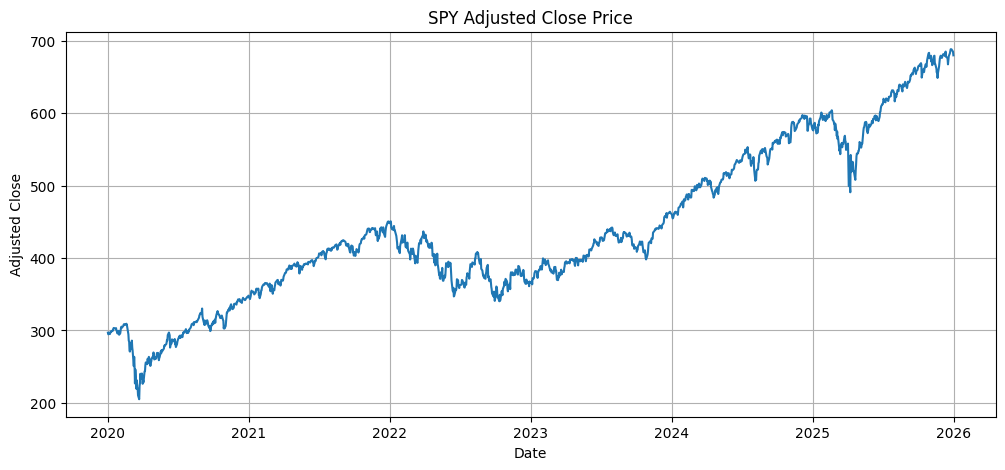

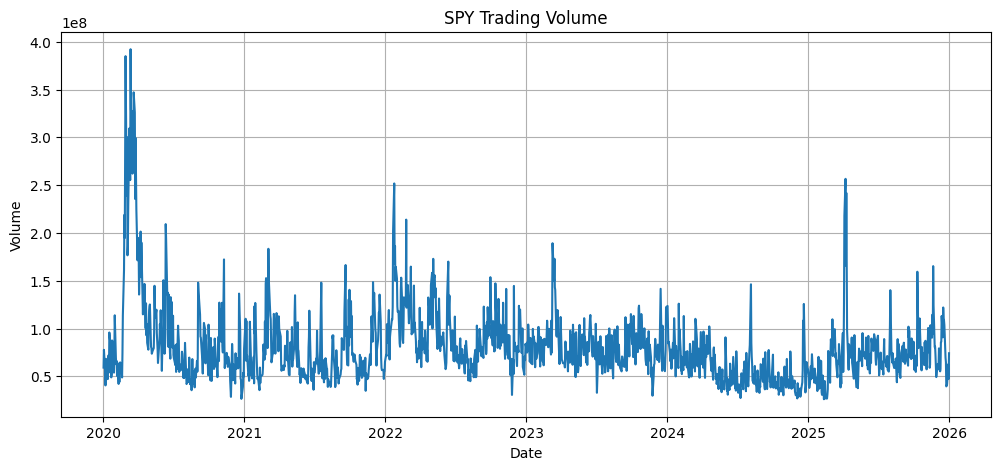

In [ ]:
# =========================
# Step 3: Price and volume visualization
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(eda_data["Date"], eda_data["Adj_Close"])
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.title("SPY Adjusted Close Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(eda_data["Date"], eda_data["Volume"])
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("SPY Trading Volume")
plt.grid(True)
plt.show()

In [ ]:
# =========================
# Step 3: Exploratory return calculation
# =========================

eda_data["Log_Return"] = np.log(eda_data["Adj_Close"]).diff()
eda_data["Simple_Return"] = eda_data["Adj_Close"].pct_change()

return_summary = eda_data[["Log_Return", "Simple_Return"]].describe().T

return_summary

,count,mean,std,min,25%,50%,75%,max
Log_Return,1507.0,0.000550,0.013101,-0.115887,-0.004856,0.000972,0.006811,0.099863
Simple_Return,1507.0,0.000636,0.013070,-0.109424,-0.004845,0.000972,0.006835,0.105019


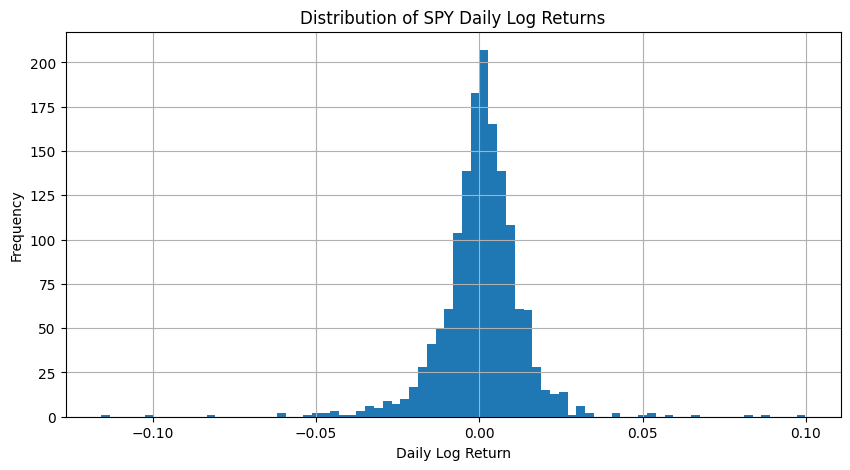

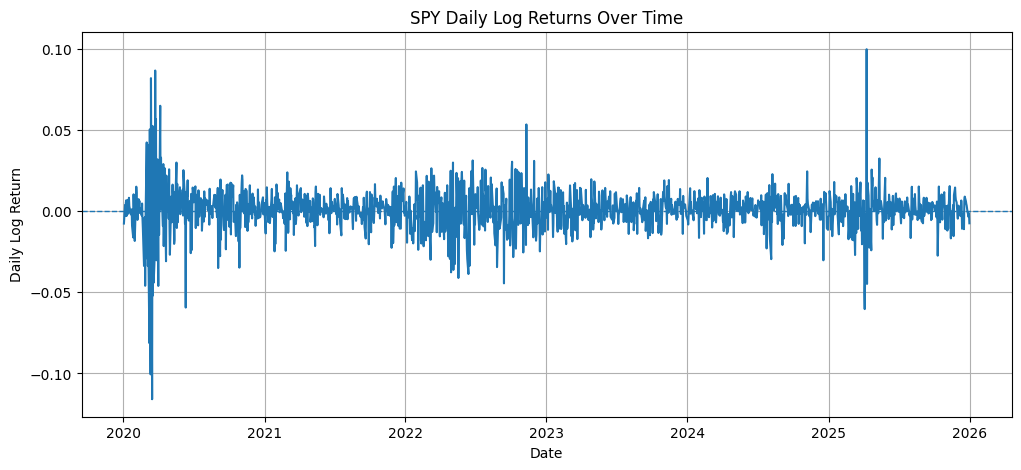

In [ ]:
# =========================
# Step 3: Return distribution
# =========================

plt.figure(figsize=(10, 5))
plt.hist(eda_data["Log_Return"].dropna(), bins=80)
plt.xlabel("Daily Log Return")
plt.ylabel("Frequency")
plt.title("Distribution of SPY Daily Log Returns")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(eda_data["Date"], eda_data["Log_Return"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Daily Log Return")
plt.title("SPY Daily Log Returns Over Time")
plt.grid(True)
plt.show()

In [ ]:
# =========================
# Step 3: Near-zero return threshold review
# =========================

threshold_candidates = [0.0000, 0.00025, 0.0005, 0.0010, 0.0025]

near_zero_results = []

valid_returns = eda_data["Log_Return"].dropna()

for threshold in threshold_candidates:
    positive_count = (valid_returns > threshold).sum()
    non_positive_count = (valid_returns <= threshold).sum()
    near_zero_count = (valid_returns.abs() <= threshold).sum()

    near_zero_results.append({
        "threshold": threshold,
        "threshold_percent": f"{threshold:.3%}",
        "positive_count": positive_count,
        "non_positive_count": non_positive_count,
        "near_zero_count": near_zero_count,
        "positive_ratio": positive_count / len(valid_returns),
        "non_positive_ratio": non_positive_count / len(valid_returns),
        "near_zero_ratio": near_zero_count / len(valid_returns)
    })

near_zero_table = pd.DataFrame(near_zero_results)

near_zero_table

,threshold,threshold_percent,positive_count,non_positive_count,near_zero_count,positive_ratio,non_positive_ratio,near_zero_ratio
0,0.00000,0.000%,831,676,2,0.551427,0.448573,0.001327
1,0.00025,0.025%,817,690,34,0.542137,0.457863,0.022561
2,0.00050,0.050%,788,719,83,0.522893,0.477107,0.055076
3,0.00100,0.100%,751,756,150,0.498341,0.501659,0.099536
4,0.00250,0.250%,636,871,368,0.422031,0.577969,0.244194


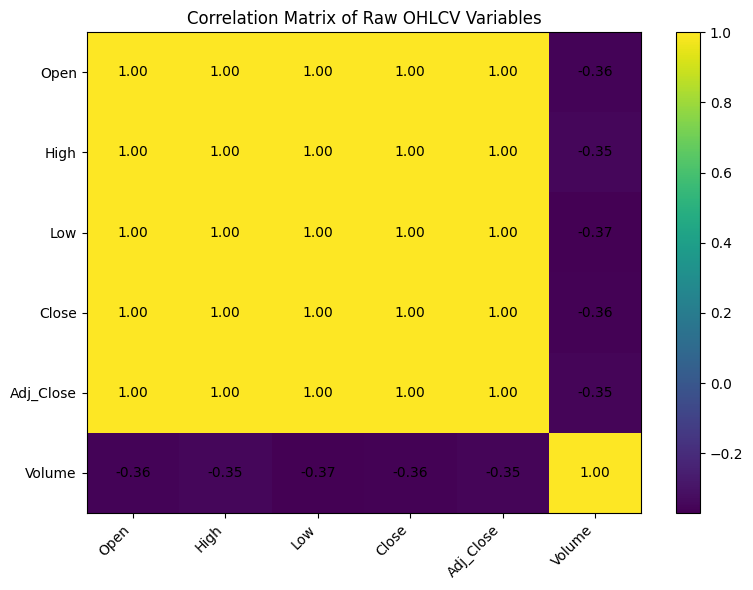

,Open,High,Low,Close,Adj_Close,Volume
Open,1.000000,0.999619,0.999582,0.999186,0.998271,-0.356780
High,0.999619,1.000000,0.999333,0.999562,0.998836,-0.346581
Low,0.999582,0.999333,1.000000,0.999577,0.998486,-0.370145
Close,0.999186,0.999562,0.999577,1.000000,0.999055,-0.360321
Adj_Close,0.998271,0.998836,0.998486,0.999055,1.000000,-0.350797
Volume,-0.356780,-0.346581,-0.370145,-0.360321,-0.350797,1.000000


In [ ]:
# =========================
# Step 3: Correlation among raw OHLCV variables
# =========================

raw_corr = eda_data[["Open", "High", "Low", "Close", "Adj_Close", "Volume"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(raw_corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(raw_corr.columns)), raw_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(raw_corr.index)), raw_corr.index)
plt.title("Correlation Matrix of Raw OHLCV Variables")

for i in range(len(raw_corr.index)):
    for j in range(len(raw_corr.columns)):
        plt.text(j, i, f"{raw_corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

raw_corr

## 3.2 Initial EDA Summary

The initial EDA confirms that the SPY dataset is suitable for the machine learning workflow. The dataset contains 1,508 daily observations from 2020-01-02 to 2025-12-31, with no duplicate dates and no material missing-value issues in the raw OHLCV variables.

The adjusted closing price shows a general upward trend over the sample period, while trading volume varies substantially over time. The daily log return series displays typical characteristics of financial returns, including a mean close to zero, volatility clustering, and several extreme observations during turbulent market periods.

The exploratory log return summary shows an average daily log return of approximately 0.055% and a standard deviation of approximately 1.31%. The distribution is centered near zero but displays fat tails, confirming that short-term market moves are noisy and difficult to predict.

The near-zero threshold analysis supports the initial threshold of 0.05%. Under this threshold, the positive class accounts for approximately 52.29% of observations, while the non-positive class accounts for approximately 47.71%. This produces a relatively balanced binary classification problem without treating very small positive returns as economically meaningful uptrends.

Therefore, the near-zero return threshold is retained at 0.05% for target construction.

# Step 4: Data Cleaning

## 4.1 Purpose of Data Cleaning

This step prepares a clean OHLCV dataset for feature engineering and model construction. Since the raw SPY data were collected from Yahoo Finance and the initial EDA did not reveal major data quality issues, the cleaning process focuses on confirming data consistency rather than aggressively modifying the dataset.

The cleaning process includes:

- Ensuring chronological ordering;
- Removing duplicate dates, if any;
- Converting price and volume fields to numeric formats;
- Checking missing values;
- Checking invalid price or volume records;
- Verifying basic OHLC consistency;
- Saving a cleaned dataset for subsequent feature engineering.

Extreme market observations are not removed at this stage because they represent real market conditions and may contain useful information for volatility and trend prediction.

In [ ]:
# =========================
# Step 4: Load raw data for cleaning
# =========================

clean_data = pd.read_csv(RAW_DATA_PATH, parse_dates=["Date"])

clean_data = clean_data.sort_values("Date").reset_index(drop=True)

print("Raw data shape:", clean_data.shape)
print("Start date:", clean_data["Date"].min())
print("End date:", clean_data["Date"].max())

clean_data.head()

Raw data shape: (1508, 7)
Start date: 2020-01-02 00:00:00
End date: 2025-12-31 00:00:00


,Date,Open,High,Low,Close,Adj_Close,Volume
0,2020-01-02,323.540009,324.890015,322.529999,324.869995,296.888184,59151200
1,2020-01-03,321.160004,323.640015,321.100006,322.410004,294.640045,77709700
2,2020-01-06,320.489990,323.730011,320.359985,323.640015,295.764038,55653900
3,2020-01-07,323.019989,323.540009,322.239990,322.730011,294.932526,40496400
4,2020-01-08,322.940002,325.779999,322.670013,324.450012,296.504364,68296000


In [ ]:
# =========================
# Step 4: Standardize data types
# =========================

numeric_columns = ["Open", "High", "Low", "Close", "Adj_Close", "Volume"]

for col in numeric_columns:
    clean_data[col] = pd.to_numeric(clean_data[col], errors="coerce")

clean_data["Date"] = pd.to_datetime(clean_data["Date"])

print("Data types after conversion:")
print(clean_data.dtypes)

Data types after conversion:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj_Close           float64
Volume                int64
dtype: object


In [ ]:
# =========================
# Step 4: Check duplicates and missing values
# =========================

duplicate_date_count = clean_data["Date"].duplicated().sum()
missing_before = clean_data.isna().sum()

print("Duplicate dates before cleaning:", duplicate_date_count)

print("\nMissing values before cleaning:")
print(missing_before)

Duplicate dates before cleaning: 0

Missing values before cleaning:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64


In [ ]:
# =========================
# Step 4: Remove duplicate dates if needed
# =========================

clean_data = clean_data.drop_duplicates(subset=["Date"], keep="first")
clean_data = clean_data.sort_values("Date").reset_index(drop=True)

duplicate_date_count_after = clean_data["Date"].duplicated().sum()

print("Duplicate dates after cleaning:", duplicate_date_count_after)
print("Data shape after duplicate removal:", clean_data.shape)

Duplicate dates after cleaning: 0
Data shape after duplicate removal: (1508, 7)


In [ ]:
# =========================
# Step 4: Check invalid price and volume records
# =========================

invalid_price_mask = (
    (clean_data["Open"] <= 0) |
    (clean_data["High"] <= 0) |
    (clean_data["Low"] <= 0) |
    (clean_data["Close"] <= 0) |
    (clean_data["Adj_Close"] <= 0)
)

invalid_volume_mask = clean_data["Volume"] < 0

invalid_price_count = invalid_price_mask.sum()
invalid_volume_count = invalid_volume_mask.sum()

print("Invalid price records:", invalid_price_count)
print("Invalid volume records:", invalid_volume_count)

if invalid_price_count > 0:
    display(clean_data.loc[invalid_price_mask].head())

if invalid_volume_count > 0:
    display(clean_data.loc[invalid_volume_mask].head())

Invalid price records: 0
Invalid volume records: 0


In [ ]:
# =========================
# Step 4: Check OHLC consistency
# =========================

ohlc_inconsistent_mask = (
    (clean_data["High"] < clean_data[["Open", "Close", "Low"]].max(axis=1)) |
    (clean_data["Low"] > clean_data[["Open", "Close", "High"]].min(axis=1))
)

ohlc_inconsistent_count = ohlc_inconsistent_mask.sum()

print("OHLC inconsistent records:", ohlc_inconsistent_count)

if ohlc_inconsistent_count > 0:
    display(clean_data.loc[ohlc_inconsistent_mask].head())

OHLC inconsistent records: 0


In [ ]:
# =========================
# Step 4: Drop rows with critical missing or invalid values
# =========================

rows_before = len(clean_data)

critical_columns = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]

clean_data = clean_data.dropna(subset=critical_columns)

clean_data = clean_data.loc[~invalid_price_mask].copy()
clean_data = clean_data.loc[~invalid_volume_mask].copy()

clean_data = clean_data.sort_values("Date").reset_index(drop=True)

rows_after = len(clean_data)
rows_removed = rows_before - rows_after

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_removed)

Rows before cleaning: 1508
Rows after cleaning: 1508
Rows removed: 0


In [ ]:
# =========================
# Step 4: Save cleaned dataset
# =========================

CLEAN_DATA_PATH = os.path.join(DATA_DIR, f"{TICKER}_clean_ohlcv.csv")

clean_data.to_csv(CLEAN_DATA_PATH, index=False)

print("Cleaned data saved to:", CLEAN_DATA_PATH)
print("Cleaned data shape:", clean_data.shape)

clean_data.head()

Cleaned data saved to: /content/data/SPY_clean_ohlcv.csv
Cleaned data shape: (1508, 7)


,Date,Open,High,Low,Close,Adj_Close,Volume
0,2020-01-02,323.540009,324.890015,322.529999,324.869995,296.888184,59151200
1,2020-01-03,321.160004,323.640015,321.100006,322.410004,294.640045,77709700
2,2020-01-06,320.489990,323.730011,320.359985,323.640015,295.764038,55653900
3,2020-01-07,323.019989,323.540009,322.239990,322.730011,294.932526,40496400
4,2020-01-08,322.940002,325.779999,322.670013,324.450012,296.504364,68296000


In [ ]:
# =========================
# Step 4: Cleaning report
# =========================

cleaning_report = pd.DataFrame({
    "item": [
        "rows_before_cleaning",
        "rows_after_cleaning",
        "rows_removed",
        "duplicate_dates_before",
        "duplicate_dates_after",
        "missing_values_after",
        "invalid_price_records",
        "invalid_volume_records",
        "ohlc_inconsistent_records"
    ],
    "value": [
        rows_before,
        rows_after,
        rows_removed,
        duplicate_date_count,
        duplicate_date_count_after,
        int(clean_data.isna().sum().sum()),
        int(invalid_price_count),
        int(invalid_volume_count),
        int(ohlc_inconsistent_count)
    ]
})

cleaning_report

,item,value
0,rows_before_cleaning,1508
1,rows_after_cleaning,1508
2,rows_removed,0
3,duplicate_dates_before,0
4,duplicate_dates_after,0
5,missing_values_after,0
6,invalid_price_records,0
7,invalid_volume_records,0
8,ohlc_inconsistent_records,0


## 4.2 Data Cleaning Summary

The raw SPY OHLCV dataset was cleaned and validated before feature construction. The cleaning procedure confirmed that the dataset is chronologically ordered and contains no duplicate dates, no critical missing values, no invalid price or volume records, and no OHLC consistency errors.

The number of observations remains unchanged after cleaning, with 1,508 rows retained. This indicates that the Yahoo Finance data are clean and suitable for feature engineering.

No aggressive outlier removal is applied because large price moves and high-volume observations may reflect genuine market stress periods. These observations may contain useful information for volatility and trend prediction and should therefore be preserved.

# Step 5: Feature Engineering and Transformation

## 5.1 Purpose of Feature Engineering

This step transforms the cleaned SPY OHLCV dataset into a supervised learning dataset for binary classification. The dependent variable is constructed from the next trading day's log return, while the explanatory variables are engineered only from information available at or before time \(t\).

The feature engineering process includes:

- Return-based features;
- Lagged return features;
- Rolling momentum features;
- Rolling volatility features;
- Price range and intraday movement features;
- Moving average features;
- Volume-based features;
- Technical indicators such as RSI, MACD, Bollinger Bands, and ATR.

The objective is to create a sufficiently broad initial feature set. A funnel-style feature selection process will then be applied to reduce this broad set to a smaller and more informative subset for the Gradient Boosting model.

## 5.2 Target Variable Construction

The prediction target is the next trading day's positive market move. Let \(r_{t+1}\) be the next-day log return of SPY. The binary label is defined as:

$$
Y_t = 1 \quad \text{if } r_{t+1} > \tau
$$

$$
Y_t = 0 \quad \text{otherwise}
$$

where \(\tau = 0.0005\), corresponding to a 0.05% near-zero return threshold.

This threshold is used to avoid classifying very small positive returns as economically meaningful uptrends. Based on the initial EDA, this threshold produces a relatively balanced binary classification problem.

In [ ]:
# =========================
# Step 5A: Load cleaned dataset
# =========================

feature_data = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["Date"])
feature_data = feature_data.sort_values("Date").reset_index(drop=True)

print("Cleaned data shape:", feature_data.shape)
print("Start date:", feature_data["Date"].min())
print("End date:", feature_data["Date"].max())

feature_data.head()

Cleaned data shape: (1508, 7)
Start date: 2020-01-02 00:00:00
End date: 2025-12-31 00:00:00


,Date,Open,High,Low,Close,Adj_Close,Volume
0,2020-01-02,323.540009,324.890015,322.529999,324.869995,296.888184,59151200
1,2020-01-03,321.160004,323.640015,321.100006,322.410004,294.640045,77709700
2,2020-01-06,320.489990,323.730011,320.359985,323.640015,295.764038,55653900
3,2020-01-07,323.019989,323.540009,322.239990,322.730011,294.932526,40496400
4,2020-01-08,322.940002,325.779999,322.670013,324.450012,296.504364,68296000


In [ ]:
# =========================
# Step 5A: Basic return and price features
# =========================

df_features = feature_data.copy()

# Daily return measures
df_features["log_return"] = np.log(df_features["Adj_Close"]).diff()
df_features["simple_return"] = df_features["Adj_Close"].pct_change()

# Next-day return used only for target construction
df_features["forward_log_return"] = df_features["log_return"].shift(-FORECAST_HORIZON)

# Binary target variable
df_features["target"] = (df_features["forward_log_return"] > NEAR_ZERO_THRESHOLD).astype(int)

# Intraday and range-based features available at time t
df_features["intraday_return"] = (df_features["Close"] - df_features["Open"]) / df_features["Open"]
df_features["high_low_range"] = (df_features["High"] - df_features["Low"]) / df_features["Open"]
df_features["close_to_high"] = (df_features["High"] - df_features["Close"]) / df_features["Open"]
df_features["close_to_low"] = (df_features["Close"] - df_features["Low"]) / df_features["Open"]

# Adjusted close relative to raw close
df_features["adj_close_ratio"] = df_features["Adj_Close"] / df_features["Close"]

df_features[[
    "Date",
    "Adj_Close",
    "log_return",
    "forward_log_return",
    "target",
    "intraday_return",
    "high_low_range"
]].head()

,Date,Adj_Close,log_return,forward_log_return,target,intraday_return,high_low_range
0,2020-01-02,296.888184,NaN,-0.007601,0,0.004111,0.007294
1,2020-01-03,294.640045,-0.007601,0.003808,1,0.003892,0.007909
2,2020-01-06,295.764038,0.003808,-0.002815,0,0.009829,0.010515
3,2020-01-07,294.932526,-0.002815,0.005315,1,-0.000898,0.004025
4,2020-01-08,296.504364,0.005315,0.006758,1,0.004676,0.009630


In [ ]:
# =========================
# Step 5A: Lagged return features
# =========================

return_lags = [1, 2, 3, 4, 5, 10]

for lag in return_lags:
    df_features[f"log_return_lag_{lag}"] = df_features["log_return"].shift(lag)
    df_features[f"simple_return_lag_{lag}"] = df_features["simple_return"].shift(lag)

df_features[[f"log_return_lag_{lag}" for lag in return_lags]].head(12)

,log_return_lag_1,log_return_lag_2,log_return_lag_3,log_return_lag_4,log_return_lag_5,log_return_lag_10
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.007601,NaN,NaN,NaN,NaN,NaN
3,0.003808,-0.007601,NaN,NaN,NaN,NaN
4,-0.002815,0.003808,-0.007601,NaN,NaN,NaN
5,0.005315,-0.002815,0.003808,-0.007601,NaN,NaN
6,0.006758,0.005315,-0.002815,0.003808,-0.007601,NaN
7,-0.002882,0.006758,0.005315,-0.002815,0.003808,NaN
8,0.006854,-0.002882,0.006758,0.005315,-0.002815,NaN
9,-0.001526,0.006854,-0.002882,0.006758,0.005315,NaN


In [ ]:
# =========================
# Step 5A: Rolling return and volatility features
# =========================

rolling_windows = [3, 5, 10, 20, 60]

for window in rolling_windows:
    df_features[f"rolling_return_{window}"] = df_features["log_return"].rolling(window).sum()
    df_features[f"rolling_mean_return_{window}"] = df_features["log_return"].rolling(window).mean()
    df_features[f"rolling_volatility_{window}"] = df_features["log_return"].rolling(window).std()
    df_features[f"rolling_skew_{window}"] = df_features["log_return"].rolling(window).skew()

    # Rolling kurtosis requires at least 4 observations.
    # Therefore, it is not computed for the 3-day window.
    if window >= 5:
        df_features[f"rolling_kurt_{window}"] = df_features["log_return"].rolling(window).kurt()

df_features[[f"rolling_return_{window}" for window in rolling_windows]].tail()

,rolling_return_3,rolling_return_5,rolling_return_10,rolling_return_20,rolling_return_60
1503,0.014282,0.030828,0.007029,0.025450,0.038633
1504,0.007970,0.023203,0.004603,0.018469,0.035130
1505,-0.000160,0.010611,0.011844,0.009456,0.030409
1506,-0.004893,0.003178,0.012134,0.012810,0.029201
1507,-0.012228,-0.008818,0.007433,0.003523,0.018185


In [ ]:
# =========================
# Step 5A: Moving average and trend features
# =========================

ma_windows = [5, 10, 20, 50, 100]

for window in ma_windows:
    df_features[f"ma_{window}"] = df_features["Adj_Close"].rolling(window).mean()
    df_features[f"price_to_ma_{window}"] = df_features["Adj_Close"] / df_features[f"ma_{window}"] - 1

# Moving average spread features
df_features["ma_5_20_spread"] = df_features["ma_5"] / df_features["ma_20"] - 1
df_features["ma_10_50_spread"] = df_features["ma_10"] / df_features["ma_50"] - 1
df_features["ma_20_100_spread"] = df_features["ma_20"] / df_features["ma_100"] - 1

df_features[[
    "Date",
    "Adj_Close",
    "price_to_ma_5",
    "price_to_ma_20",
    "ma_5_20_spread"
]].tail()

,Date,Adj_Close,price_to_ma_5,price_to_ma_20,ma_5_20_spread
1503,2025-12-24,688.499695,0.009848,0.013544,0.003660
1504,2025-12-26,688.429871,0.005090,0.012502,0.007374
1505,2025-12-29,685.976562,-0.000604,0.008415,0.009025
1506,2025-12-30,685.138916,-0.002457,0.006539,0.009017
1507,2025-12-31,680.062744,-0.008108,-0.001094,0.007071


In [ ]:
# =========================
# Step 5A: Volume-based features
# =========================

df_features["volume_change"] = df_features["Volume"].pct_change()
df_features["log_volume"] = np.log(df_features["Volume"])

volume_windows = [5, 10, 20, 60]

for window in volume_windows:
    df_features[f"volume_ma_{window}"] = df_features["Volume"].rolling(window).mean()
    df_features[f"volume_to_ma_{window}"] = df_features["Volume"] / df_features[f"volume_ma_{window}"] - 1
    df_features[f"volume_change_ma_{window}"] = df_features["volume_change"].rolling(window).mean()

df_features[[
    "Date",
    "Volume",
    "volume_change",
    "volume_to_ma_20"
]].tail()

,Date,Volume,volume_change,volume_to_ma_20
1503,2025-12-24,39445600,-0.391647,-0.491616
1504,2025-12-26,41613300,0.054954,-0.453009
1505,2025-12-29,62559500,0.503353,-0.184830
1506,2025-12-30,47160700,-0.246146,-0.379808
1507,2025-12-31,74144800,0.572173,-0.032074


In [ ]:
# =========================
# Step 5A: RSI indicator
# =========================

def compute_rsi(series, window=14):
    """Compute the Relative Strength Index."""
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

df_features["rsi_14"] = compute_rsi(df_features["Adj_Close"], window=14)
df_features["rsi_7"] = compute_rsi(df_features["Adj_Close"], window=7)

df_features[["Date", "Adj_Close", "rsi_7", "rsi_14"]].tail()

,Date,Adj_Close,rsi_7,rsi_14
1503,2025-12-24,688.499695,69.258695,58.215674
1504,2025-12-26,688.429871,73.598807,56.989641
1505,2025-12-29,685.976562,89.228492,56.506570
1506,2025-12-30,685.138916,82.514631,56.211350
1507,2025-12-31,680.062744,53.643781,46.281302


In [ ]:
# =========================
# Step 5A: MACD indicator
# =========================

ema_12 = df_features["Adj_Close"].ewm(span=12, adjust=False).mean()
ema_26 = df_features["Adj_Close"].ewm(span=26, adjust=False).mean()

df_features["macd"] = ema_12 - ema_26
df_features["macd_signal"] = df_features["macd"].ewm(span=9, adjust=False).mean()
df_features["macd_hist"] = df_features["macd"] - df_features["macd_signal"]

df_features[["Date", "macd", "macd_signal", "macd_hist"]].tail()

,Date,macd,macd_signal,macd_hist
1503,2025-12-24,3.219095,2.559720,0.659375
1504,2025-12-26,3.648904,2.777557,0.871348
1505,2025-12-29,3.748362,2.971718,0.776644
1506,2025-12-30,3.716747,3.120723,0.596023
1507,2025-12-31,3.244684,3.145516,0.099169


In [ ]:
# =========================
# Step 5A: Bollinger Bands
# =========================

bb_window = 20

bb_middle = df_features["Adj_Close"].rolling(bb_window).mean()
bb_std = df_features["Adj_Close"].rolling(bb_window).std()

df_features["bb_middle_20"] = bb_middle
df_features["bb_upper_20"] = bb_middle + 2 * bb_std
df_features["bb_lower_20"] = bb_middle - 2 * bb_std

df_features["bb_width_20"] = (df_features["bb_upper_20"] - df_features["bb_lower_20"]) / df_features["bb_middle_20"]
df_features["bb_position_20"] = (df_features["Adj_Close"] - df_features["bb_lower_20"]) / (
    df_features["bb_upper_20"] - df_features["bb_lower_20"]
)

df_features[[
    "Date",
    "Adj_Close",
    "bb_width_20",
    "bb_position_20"
]].tail()

,Date,Adj_Close,bb_width_20,bb_position_20
1503,2025-12-24,688.499695,0.028276,0.978976
1504,2025-12-26,688.429871,0.030225,0.913629
1505,2025-12-29,685.976562,0.031227,0.769479
1506,2025-12-30,685.138916,0.031364,0.708476
1507,2025-12-31,680.062744,0.031097,0.464811


In [ ]:
# =========================
# Step 5A: ATR and volatility range features
# =========================

previous_close = df_features["Close"].shift(1)

true_range_1 = df_features["High"] - df_features["Low"]
true_range_2 = (df_features["High"] - previous_close).abs()
true_range_3 = (df_features["Low"] - previous_close).abs()

df_features["true_range"] = pd.concat(
    [true_range_1, true_range_2, true_range_3],
    axis=1
).max(axis=1)

df_features["atr_14"] = df_features["true_range"].rolling(14).mean()
df_features["atr_14_pct"] = df_features["atr_14"] / df_features["Close"]

df_features[["Date", "true_range", "atr_14", "atr_14_pct"]].tail()

,Date,true_range,atr_14,atr_14_pct
1503,2025-12-24,3.030029,6.039289,0.008748
1504,2025-12-26,2.389954,5.924286,0.008582
1505,2025-12-29,4.239990,5.864999,0.008527
1506,2025-12-30,1.979980,5.806427,0.008452
1507,2025-12-31,5.649963,5.662855,0.008304


In [ ]:
# =========================
# Step 5A: Define candidate feature columns
# =========================

excluded_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj_Close",
    "Volume",
    "forward_log_return",
    "target"
]

candidate_feature_cols = [
    col for col in df_features.columns
    if col not in excluded_columns
]

candidate_feature_count = len(candidate_feature_cols)

print("Number of candidate features:", candidate_feature_count)
print("Candidate feature columns:")
candidate_feature_cols

Number of candidate features: 83
Candidate feature columns:


['log_return',
 'simple_return',
 'intraday_return',
 'high_low_range',
 'close_to_high',
 'close_to_low',
 'adj_close_ratio',
 'log_return_lag_1',
 'simple_return_lag_1',
 'log_return_lag_2',
 'simple_return_lag_2',
 'log_return_lag_3',
 'simple_return_lag_3',
 'log_return_lag_4',
 'simple_return_lag_4',
 'log_return_lag_5',
 'simple_return_lag_5',
 'log_return_lag_10',
 'simple_return_lag_10',
 'rolling_return_3',
 'rolling_mean_return_3',
 'rolling_volatility_3',
 'rolling_skew_3',
 'rolling_return_5',
 'rolling_mean_return_5',
 'rolling_volatility_5',
 'rolling_skew_5',
 'rolling_kurt_5',
 'rolling_return_10',
 'rolling_mean_return_10',
 'rolling_volatility_10',
 'rolling_skew_10',
 'rolling_kurt_10',
 'rolling_return_20',
 'rolling_mean_return_20',
 'rolling_volatility_20',
 'rolling_skew_20',
 'rolling_kurt_20',
 'rolling_return_60',
 'rolling_mean_return_60',
 'rolling_volatility_60',
 'rolling_skew_60',
 'rolling_kurt_60',
 'ma_5',
 'price_to_ma_5',
 'ma_10',
 'price_to_ma_10',

In [ ]:
# =========================
# Step 5A: Clean feature dataset and save
# =========================

feature_dataset = df_features[["Date", "target", "forward_log_return"] + candidate_feature_cols].copy()

# Replace infinite values with missing values.
feature_dataset = feature_dataset.replace([np.inf, -np.inf], np.nan)

# Drop columns that are completely missing.
all_missing_cols = feature_dataset.columns[feature_dataset.isna().all()].tolist()

if len(all_missing_cols) > 0:
    print("Columns dropped because they are completely missing:")
    print(all_missing_cols)
    feature_dataset = feature_dataset.drop(columns=all_missing_cols)

# Update candidate feature columns after dropping invalid columns.
candidate_feature_cols = [
    col for col in candidate_feature_cols
    if col in feature_dataset.columns
]

# Drop rows with missing values created by lags, rolling windows, and forward target construction.
rows_before_feature_drop = len(feature_dataset)
feature_dataset = feature_dataset.dropna().reset_index(drop=True)
rows_after_feature_drop = len(feature_dataset)
rows_removed_feature_drop = rows_before_feature_drop - rows_after_feature_drop

FEATURE_DATA_PATH = os.path.join(DATA_DIR, f"{TICKER}_feature_dataset.csv")
feature_dataset.to_csv(FEATURE_DATA_PATH, index=False)

print("Feature dataset shape:", feature_dataset.shape)
print("Rows before dropping missing feature rows:", rows_before_feature_drop)
print("Rows after dropping missing feature rows:", rows_after_feature_drop)
print("Rows removed:", rows_removed_feature_drop)
print("Number of candidate features after cleaning:", len(candidate_feature_cols))
print("Saved feature dataset to:", FEATURE_DATA_PATH)

feature_dataset.head()

Feature dataset shape: (1408, 86)
Rows before dropping missing feature rows: 1508
Rows after dropping missing feature rows: 1408
Rows removed: 100
Number of candidate features after cleaning: 83
Saved feature dataset to: /content/data/SPY_feature_dataset.csv


,Date,target,forward_log_return,log_return,simple_return,intraday_return,high_low_range,close_to_high,close_to_low,adj_close_ratio,...,macd_signal,macd_hist,bb_middle_20,bb_upper_20,bb_lower_20,bb_width_20,bb_position_20,true_range,atr_14,atr_14_pct
0,2020-05-26,1,0.014769,0.012246,0.012321,-0.009439,0.022290,0.010300,0.011990,0.919242,...,3.824681,0.525503,266.196692,275.789988,256.603395,0.072077,0.955009,6.750000,6.173571,0.020642
1,2020-05-27,0,-0.001847,0.014769,0.014879,0.004667,0.022177,0.000132,0.022044,0.919242,...,4.031124,0.825772,267.014816,278.022837,256.006795,0.082453,1.045174,6.700012,6.317858,0.020815
2,2020-05-28,1,0.004446,-0.001847,-0.001845,-0.005515,0.015099,0.012703,0.002396,0.919241,...,4.256394,0.901079,267.463406,279.578657,255.348156,0.090594,0.955588,4.600006,6.251430,0.020634
3,2020-05-29,1,0.004033,0.004446,0.004456,0.006150,0.018151,0.002116,0.016035,0.919242,...,4.491754,0.941442,268.099524,281.395482,254.803565,0.099187,0.937881,5.489990,6.267142,0.020594
4,2020-06-01,1,0.008246,0.004033,0.004041,0.006357,0.010375,0.002174,0.008201,0.919241,...,4.728901,0.948586,269.145616,283.022097,255.269135,0.103115,0.922605,3.149994,6.197856,0.020284


In [ ]:
# =========================
# Step 5A: Label distribution
# =========================

label_distribution = pd.DataFrame({
    "count": feature_dataset["target"].value_counts().sort_index(),
    "ratio": feature_dataset["target"].value_counts(normalize=True).sort_index()
})

label_distribution

,count,ratio
target,,
0,671,0.476562
1,737,0.523438


In [ ]:
# =========================
# Step 5A: Missing-value check after feature construction
# =========================

feature_missing_summary = feature_dataset.isna().sum().sort_values(ascending=False)

print("Total missing values after feature construction:", int(feature_missing_summary.sum()))

feature_missing_summary.head(10)

Total missing values after feature construction: 0


,0
Date,0
target,0
forward_log_return,0
log_return,0
simple_return,0
intraday_return,0
high_low_range,0
close_to_high,0
close_to_low,0
adj_close_ratio,0


In [ ]:
# =========================
# Step 5A: Feature dataset preview
# =========================

print("Final feature dataset shape:", feature_dataset.shape)
print("Number of candidate features:", len(candidate_feature_cols))
print("Start date:", feature_dataset["Date"].min())
print("End date:", feature_dataset["Date"].max())

feature_dataset.tail()

Final feature dataset shape: (1408, 86)
Number of candidate features: 83
Start date: 2020-05-26 00:00:00
End date: 2025-12-30 00:00:00


,Date,target,forward_log_return,log_return,simple_return,intraday_return,high_low_range,close_to_high,close_to_low,adj_close_ratio,...,macd_signal,macd_hist,bb_middle_20,bb_upper_20,bb_lower_20,bb_width_20,bb_position_20,true_range,atr_14,atr_14_pct
1403,2025-12-23,1,0.003511,0.004560,0.004570,0.005907,0.006331,0.000351,0.005980,0.997276,...,2.394876,0.221692,678.434381,687.658503,669.210260,0.027192,0.914778,4.330017,6.110713,0.008882
1404,2025-12-24,0,-0.000101,0.003511,0.003518,0.003532,0.004404,0.000654,0.003750,0.997276,...,2.559720,0.659375,679.299457,688.903533,669.695381,0.028276,0.978976,3.030029,6.039289,0.008748
1405,2025-12-26,0,-0.003570,-0.000101,-0.000101,-0.000478,0.003460,0.001955,0.001506,0.997276,...,2.777557,0.871348,679.929358,690.204893,669.653823,0.030225,0.913629,2.389954,5.924286,0.008582
1406,2025-12-29,0,-0.001222,-0.003570,-0.003564,0.000451,0.004552,0.001964,0.002589,0.997276,...,2.971718,0.776644,680.252145,690.873419,669.630872,0.031227,0.769479,4.239990,5.864999,0.008527
1407,2025-12-30,0,-0.007437,-0.001222,-0.001221,-0.000640,0.002880,0.002255,0.000625,0.997276,...,3.120723,0.596023,680.688165,691.362640,670.013690,0.031364,0.708476,1.979980,5.806427,0.008452


## 5.3 Feature Engineering Summary

A broad candidate feature set was created from the cleaned SPY OHLCV data. The engineered features include lagged returns, rolling returns, rolling mean returns, volatility measures, moving average relationships, volume dynamics, and several technical indicators such as RSI, MACD, Bollinger Bands, and ATR.

The binary target variable is constructed using next-day log returns and a near-zero return threshold of 0.05%. Observations with insufficient lagged or rolling information are removed after feature construction. The longest moving average window and rolling features require an initial warm-up period, and the final observation cannot be used because the next-day return is unavailable.

After removing incomplete rows and dropping the invalid three-day rolling kurtosis feature, the final supervised learning dataset contains 1,408 observations and 83 candidate features. The target distribution is relatively balanced, with approximately 52.34% positive observations and 47.66% non-positive observations.

This broad feature universe provides the input for the funnel-style feature selection process required in Question B.

## 5.4 Funnel-Style Feature Selection

The exam requires a funnel-style feature selection process combining filter, wrapper, and embedded methods. The purpose of this step is to reduce the broad candidate feature set into a smaller and more informative subset before fitting the final Gradient Boosting classifier.

To avoid data leakage, feature selection is performed only on the training sample. The final test sample is kept untouched and will only be used later for out-of-sample evaluation.

The feature selection funnel consists of three stages:

1. Filter methods  
   - Remove near-constant features;
   - Remove highly correlated features;
   - Retain the most informative features based on mutual information.

2. Wrapper method  
   - Apply recursive feature elimination with time-series cross-validation.

3. Embedded method  
   - Fit a tree-based classifier and retain features with high model-based importance.

The output of this step is the final selected feature set that will be used in the Gradient Boosting modeling stage.

In [ ]:
# =========================
# Step 5B: Load feature dataset
# =========================

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import json

feature_dataset = pd.read_csv(FEATURE_DATA_PATH, parse_dates=["Date"])
feature_dataset = feature_dataset.sort_values("Date").reset_index(drop=True)

# Define feature columns by excluding non-feature columns.
non_feature_cols = ["Date", "target", "forward_log_return"]

candidate_feature_cols = [
    col for col in feature_dataset.columns
    if col not in non_feature_cols
]

print("Feature dataset shape:", feature_dataset.shape)
print("Number of candidate features:", len(candidate_feature_cols))
print("Start date:", feature_dataset["Date"].min())
print("End date:", feature_dataset["Date"].max())

feature_dataset.head()

Feature dataset shape: (1408, 86)
Number of candidate features: 83
Start date: 2020-05-26 00:00:00
End date: 2025-12-30 00:00:00


,Date,target,forward_log_return,log_return,simple_return,intraday_return,high_low_range,close_to_high,close_to_low,adj_close_ratio,...,macd_signal,macd_hist,bb_middle_20,bb_upper_20,bb_lower_20,bb_width_20,bb_position_20,true_range,atr_14,atr_14_pct
0,2020-05-26,1,0.014769,0.012246,0.012321,-0.009439,0.022290,0.010300,0.011990,0.919242,...,3.824681,0.525503,266.196692,275.789988,256.603395,0.072077,0.955009,6.750000,6.173571,0.020642
1,2020-05-27,0,-0.001847,0.014769,0.014879,0.004667,0.022177,0.000132,0.022044,0.919242,...,4.031124,0.825772,267.014816,278.022837,256.006795,0.082453,1.045174,6.700012,6.317858,0.020815
2,2020-05-28,1,0.004446,-0.001847,-0.001845,-0.005515,0.015099,0.012703,0.002396,0.919241,...,4.256394,0.901079,267.463406,279.578657,255.348156,0.090594,0.955588,4.600006,6.251430,0.020634
3,2020-05-29,1,0.004033,0.004446,0.004456,0.006150,0.018151,0.002116,0.016035,0.919242,...,4.491754,0.941442,268.099524,281.395482,254.803565,0.099187,0.937881,5.489990,6.267142,0.020594
4,2020-06-01,1,0.008246,0.004033,0.004041,0.006357,0.010375,0.002174,0.008201,0.919241,...,4.728901,0.948586,269.145616,283.022097,255.269135,0.103115,0.922605,3.149994,6.197856,0.020284


In [ ]:
# =========================
# Step 5B: Chronological train-test split
# =========================

split_idx = int(len(feature_dataset) * TRAIN_RATIO)

train_feature_data = feature_dataset.iloc[:split_idx].copy()
test_feature_data = feature_dataset.iloc[split_idx:].copy()

X_train_full = train_feature_data[candidate_feature_cols].copy()
y_train_full = train_feature_data["target"].copy()

X_test_full = test_feature_data[candidate_feature_cols].copy()
y_test = test_feature_data["target"].copy()

print("Training feature data shape:", X_train_full.shape)
print("Test feature data shape:", X_test_full.shape)

print("Training period:", train_feature_data["Date"].min(), "to", train_feature_data["Date"].max())
print("Test period:", test_feature_data["Date"].min(), "to", test_feature_data["Date"].max())

print("\nTraining label distribution:")
print(y_train_full.value_counts(normalize=True).sort_index())

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training feature data shape: (1126, 83)
Test feature data shape: (282, 83)
Training period: 2020-05-26 00:00:00 to 2024-11-12 00:00:00
Test period: 2024-11-13 00:00:00 to 2025-12-30 00:00:00

Training label distribution:
target
0    0.478686
1    0.521314
Name: proportion, dtype: float64

Test label distribution:
target
0    0.468085
1    0.531915
Name: proportion, dtype: float64


### 5.4.1 Filter Stage 1: Near-Constant Feature Removal

The first filter step removes near-constant features. Features with almost no variation are unlikely to contribute useful predictive information and may create numerical instability.

This step is fitted only on the training data. The same retained feature list is then applied to the test data later.

In [ ]:
# =========================
# Step 5B: Filter method 1 - Variance threshold
# =========================

variance_threshold = 1e-10

variance_filter = VarianceThreshold(threshold=variance_threshold)
variance_filter.fit(X_train_full)

variance_selected_features = X_train_full.columns[variance_filter.get_support()].tolist()
variance_removed_features = [
    col for col in candidate_feature_cols
    if col not in variance_selected_features
]

print("Initial feature count:", len(candidate_feature_cols))
print("Features retained after variance filter:", len(variance_selected_features))
print("Features removed by variance filter:", len(variance_removed_features))
print("Removed features:", variance_removed_features)

Initial feature count: 83
Features retained after variance filter: 83
Features removed by variance filter: 0
Removed features: []


### 5.4.2 Filter Stage 2: Correlation Screening

The second filter step removes highly correlated features. Many technical indicators are mechanically related to each other, especially moving averages, rolling returns, and price-based variables. Highly correlated features may add redundancy without improving predictive power.

For each pair of features with absolute correlation above 0.95, the feature with the lower absolute correlation with the training label is removed.

In [ ]:
# =========================
# Step 5B: Filter method 2 - Correlation screening
# =========================

def remove_highly_correlated_features(X, y, feature_cols, threshold=0.95):
    """Remove highly correlated features using training data only."""

    corr_matrix = X[feature_cols].corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    target_corr = X[feature_cols].corrwith(y).abs().fillna(0)

    features_to_drop = set()

    for col in upper_triangle.columns:
        correlated_rows = upper_triangle.index[upper_triangle[col] > threshold].tolist()

        for row_feature in correlated_rows:
            if col in features_to_drop or row_feature in features_to_drop:
                continue

            if target_corr[col] >= target_corr[row_feature]:
                features_to_drop.add(row_feature)
            else:
                features_to_drop.add(col)

    selected_features = [
        feature for feature in feature_cols
        if feature not in features_to_drop
    ]

    return selected_features, sorted(list(features_to_drop)), corr_matrix, target_corr

correlation_threshold = 0.95

corr_selected_features, corr_removed_features, train_corr_matrix, train_target_corr = remove_highly_correlated_features(
    X=X_train_full,
    y=y_train_full,
    feature_cols=variance_selected_features,
    threshold=correlation_threshold
)

print("Features before correlation filter:", len(variance_selected_features))
print("Features retained after correlation filter:", len(corr_selected_features))
print("Features removed by correlation filter:", len(corr_removed_features))

corr_removed_features

Features before correlation filter: 83
Features retained after correlation filter: 63
Features removed by correlation filter: 20


['bb_lower_20',
 'bb_middle_20',
 'bb_upper_20',
 'log_return_lag_1',
 'log_return_lag_3',
 'log_return_lag_4',
 'ma_10',
 'ma_20',
 'ma_5',
 'ma_50',
 'macd_signal',
 'rolling_mean_return_3',
 'rolling_mean_return_60',
 'rolling_return_10',
 'rolling_return_20',
 'rolling_return_5',
 'simple_return',
 'simple_return_lag_10',
 'simple_return_lag_2',
 'simple_return_lag_5']

In [ ]:
# =========================
# Step 5B: Save correlation screening details
# =========================

corr_removed_df = pd.DataFrame({
    "removed_feature": corr_removed_features
})

CORR_REMOVED_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_correlation_removed_features.csv")
corr_removed_df.to_csv(CORR_REMOVED_PATH, index=False)

print("Correlation-removed feature list saved to:", CORR_REMOVED_PATH)

corr_removed_df.head(20)

Correlation-removed feature list saved to: /content/outputs/SPY_correlation_removed_features.csv


,removed_feature
0,bb_lower_20
1,bb_middle_20
2,bb_upper_20
3,log_return_lag_1
4,log_return_lag_3
5,log_return_lag_4
6,ma_10
7,ma_20
8,ma_5
9,ma_50


### 5.4.3 Filter Stage 3: Mutual Information Ranking

The third filter step ranks the remaining features using mutual information with the binary target. Mutual information is a non-parametric measure that can capture nonlinear dependence between a feature and the target variable.

The top-ranked features are retained for the wrapper stage. This creates a manageable feature subset before recursive feature elimination.

In [ ]:
# =========================
# Step 5B: Filter method 3 - Mutual information ranking
# =========================

mi_feature_count = min(50, len(corr_selected_features))

X_mi = X_train_full[corr_selected_features].copy()

mi_scores = mutual_info_classif(
    X_mi,
    y_train_full,
    random_state=42
)

mi_table = pd.DataFrame({
    "feature": corr_selected_features,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

mi_selected_features = mi_table.head(mi_feature_count)["feature"].tolist()

print("Features before mutual information filter:", len(corr_selected_features))
print("Features retained after mutual information filter:", len(mi_selected_features))

mi_table.head(20)

Features before mutual information filter: 63
Features retained after mutual information filter: 50


,feature,mutual_information
0,log_return_lag_5,0.039176
1,rolling_kurt_5,0.025721
2,atr_14,0.023056
3,adj_close_ratio,0.022754
4,rolling_volatility_60,0.022021
5,volume_change_ma_20,0.020004
6,volume_ma_60,0.019930
7,rolling_volatility_10,0.019708
8,rsi_14,0.018276
9,volume_ma_5,0.017873


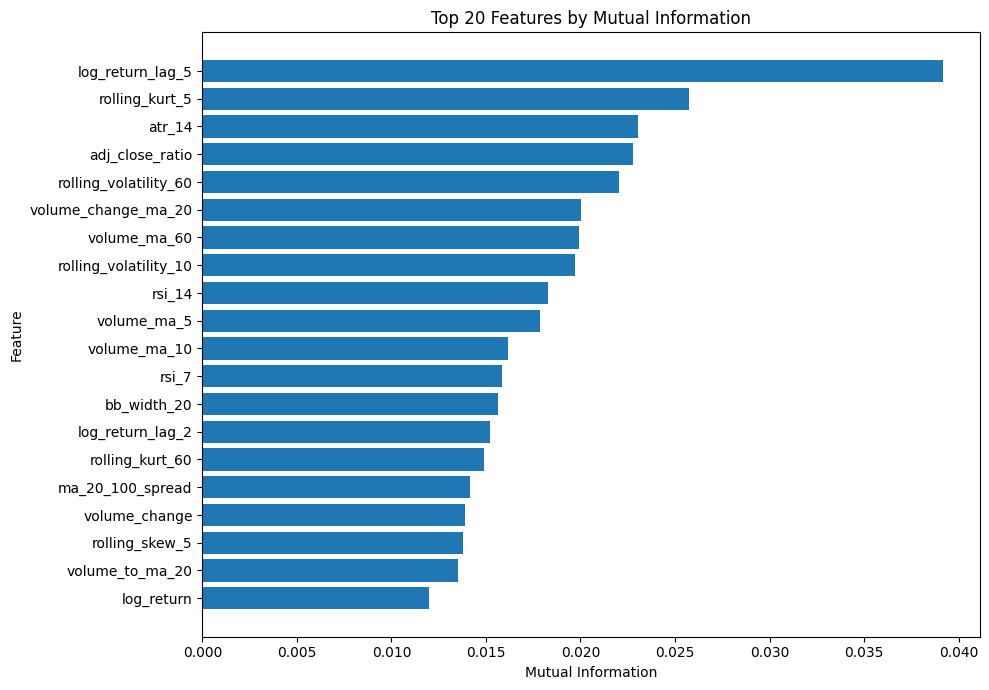

In [ ]:
# =========================
# Step 5B: Plot top mutual information features
# =========================

top_mi = mi_table.head(20).sort_values("mutual_information", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_mi["feature"], top_mi["mutual_information"])
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Top 20 Features by Mutual Information")
plt.tight_layout()
plt.show()

### 5.4.4 Wrapper Stage: Recursive Feature Elimination

The wrapper step applies recursive feature elimination with time-series cross-validation. A logistic regression classifier is used as the base estimator because it provides a stable and interpretable linear benchmark for feature ranking.

The objective of this stage is not to build the final model, but to identify a feature subset that performs reasonably well under a validation framework that preserves chronological order.

In [ ]:
# =========================
# Step 5B: Wrapper method - RFECV
# =========================

X_wrapper = X_train_full[mi_selected_features].copy()

# Scale features for logistic regression.
scaler_wrapper = StandardScaler()
X_wrapper_scaled = scaler_wrapper.fit_transform(X_wrapper)

tscv = TimeSeriesSplit(n_splits=5)

wrapper_estimator = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

rfecv = RFECV(
    estimator=wrapper_estimator,
    step=5,
    min_features_to_select=20,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1
)

rfecv.fit(X_wrapper_scaled, y_train_full)

wrapper_selected_features = [
    feature for feature, selected in zip(mi_selected_features, rfecv.support_)
    if selected
]

wrapper_removed_features = [
    feature for feature in mi_selected_features
    if feature not in wrapper_selected_features
]

print("Features before wrapper selection:", len(mi_selected_features))
print("Optimal number of features selected by RFECV:", rfecv.n_features_)
print("Features retained after wrapper selection:", len(wrapper_selected_features))
print("Features removed by wrapper selection:", len(wrapper_removed_features))

wrapper_selected_features

Features before wrapper selection: 50
Optimal number of features selected by RFECV: 20
Features retained after wrapper selection: 20
Features removed by wrapper selection: 30


['volume_change_ma_20',
 'volume_ma_60',
 'rolling_volatility_10',
 'volume_ma_5',
 'volume_ma_10',
 'rolling_kurt_60',
 'ma_20_100_spread',
 'volume_to_ma_20',
 'price_to_ma_50',
 'price_to_ma_100',
 'rolling_mean_return_10',
 'log_volume',
 'rolling_mean_return_20',
 'intraday_return',
 'rolling_volatility_20',
 'rolling_volatility_5',
 'close_to_low',
 'log_return_lag_10',
 'volume_to_ma_5',
 'price_to_ma_10']

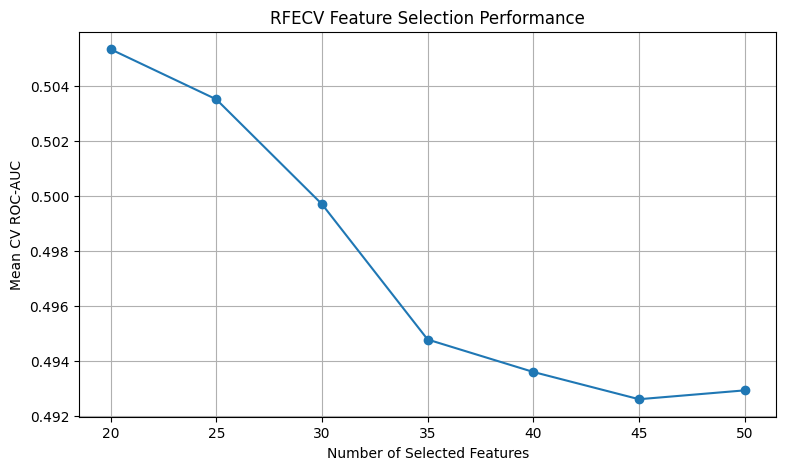

,n_features,mean_cv_roc_auc
0,20,0.505347
1,25,0.503523
2,30,0.499708
3,35,0.494782
4,40,0.493601
6,50,0.492931
5,45,0.492609


In [ ]:
# =========================
# Step 5B: RFECV performance curve
# =========================

rfecv_scores = rfecv.cv_results_["mean_test_score"]
rfecv_n_features = rfecv.cv_results_["n_features"]

plt.figure(figsize=(9, 5))
plt.plot(rfecv_n_features, rfecv_scores, marker="o")
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV ROC-AUC")
plt.title("RFECV Feature Selection Performance")
plt.grid(True)
plt.show()

rfecv_summary = pd.DataFrame({
    "n_features": rfecv_n_features,
    "mean_cv_roc_auc": rfecv_scores
})

rfecv_summary.sort_values("mean_cv_roc_auc", ascending=False).head(10)

### 5.4.5 Embedded Stage: Tree-Based Feature Importance

The embedded step uses a Gradient Boosting classifier to estimate feature importance from the wrapper-selected feature set. Tree-based models naturally capture nonlinear relationships and interactions among features.

The final selected features are chosen based on cumulative feature importance. This step aligns the feature selection process with the final modeling family, since the final classifier will also be based on Gradient Boosting.

In [ ]:
# =========================
# Step 5B: Embedded method - Gradient Boosting feature importance
# =========================

X_embedded = X_train_full[wrapper_selected_features].copy()

embedded_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

embedded_model.fit(X_embedded, y_train_full)

embedded_importance = pd.DataFrame({
    "feature": wrapper_selected_features,
    "importance": embedded_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

embedded_importance["cumulative_importance"] = embedded_importance["importance"].cumsum()

embedded_importance.head(20)

,feature,importance,cumulative_importance
0,volume_change_ma_20,0.096509,0.096509
1,price_to_ma_50,0.083057,0.179566
2,volume_ma_60,0.075906,0.255472
3,log_return_lag_10,0.074324,0.329796
4,rolling_kurt_60,0.072634,0.402430
5,rolling_volatility_5,0.064775,0.467205
6,rolling_mean_return_20,0.056221,0.523426
7,close_to_low,0.056106,0.579533
8,volume_ma_5,0.051736,0.631269
9,price_to_ma_100,0.050552,0.681820


In [ ]:
# =========================
# Step 5B: Final selected features
# =========================

importance_threshold = 0.95
minimum_feature_count = 12
maximum_feature_count = 25

features_by_importance = embedded_importance[
    embedded_importance["cumulative_importance"] <= importance_threshold
]["feature"].tolist()

# Ensure at least a minimum number of features are retained.
if len(features_by_importance) < minimum_feature_count:
    features_by_importance = embedded_importance.head(minimum_feature_count)["feature"].tolist()

# Limit the final feature set to avoid excessive model complexity.
final_selected_features = features_by_importance[:maximum_feature_count]

print("Features before embedded selection:", len(wrapper_selected_features))
print("Final selected feature count:", len(final_selected_features))

final_selected_features

Features before embedded selection: 20
Final selected feature count: 17


['volume_change_ma_20',
 'price_to_ma_50',
 'volume_ma_60',
 'log_return_lag_10',
 'rolling_kurt_60',
 'rolling_volatility_5',
 'rolling_mean_return_20',
 'close_to_low',
 'volume_ma_5',
 'price_to_ma_100',
 'rolling_mean_return_10',
 'volume_to_ma_5',
 'rolling_volatility_20',
 'price_to_ma_10',
 'volume_to_ma_20',
 'rolling_volatility_10',
 'intraday_return']

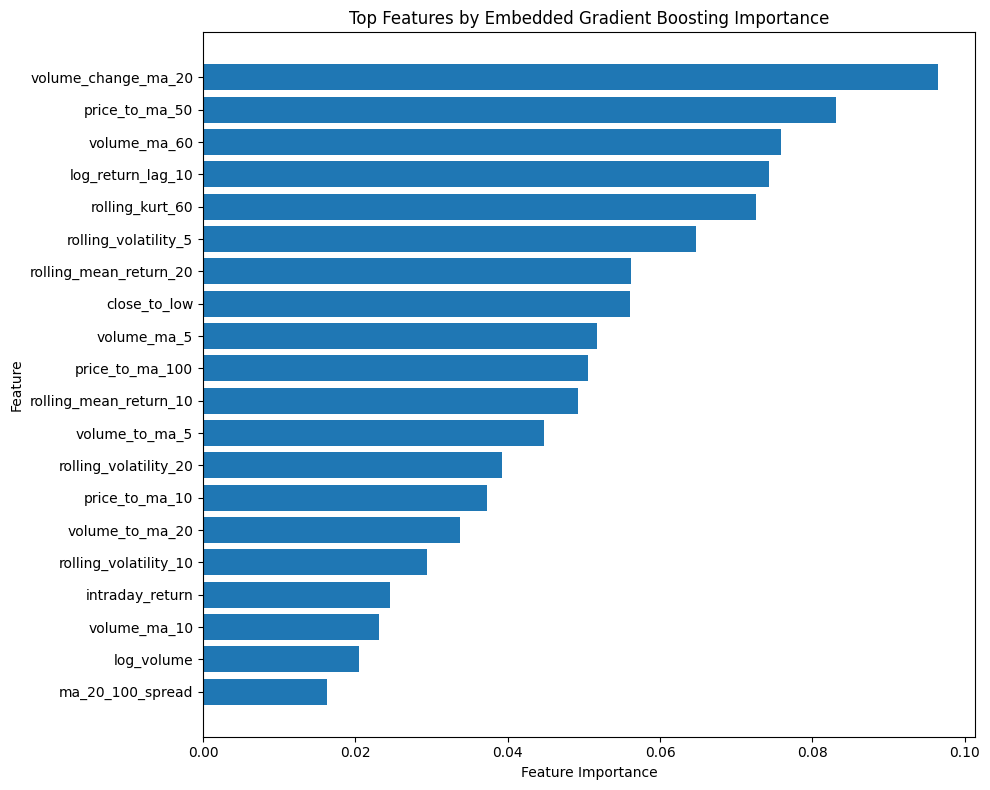

In [ ]:
# =========================
# Step 5B: Plot embedded feature importance
# =========================

top_embedded = embedded_importance.head(25).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_embedded["feature"], top_embedded["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features by Embedded Gradient Boosting Importance")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Step 5B: Feature selection summary
# =========================

feature_selection_summary = pd.DataFrame({
    "stage": [
        "Initial candidate features",
        "After variance filter",
        "After correlation filter",
        "After mutual information filter",
        "After wrapper RFECV",
        "After embedded Gradient Boosting"
    ],
    "number_of_features": [
        len(candidate_feature_cols),
        len(variance_selected_features),
        len(corr_selected_features),
        len(mi_selected_features),
        len(wrapper_selected_features),
        len(final_selected_features)
    ]
})

feature_selection_summary

,stage,number_of_features
0,Initial candidate features,83
1,After variance filter,83
2,After correlation filter,63
3,After mutual information filter,50
4,After wrapper RFECV,20
5,After embedded Gradient Boosting,17


In [ ]:
# =========================
# Step 5B: Save selected features and feature selection outputs
# =========================

SELECTED_FEATURES_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_final_selected_features.json")
FEATURE_SELECTION_SUMMARY_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_feature_selection_summary.csv")
EMBEDDED_IMPORTANCE_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_embedded_feature_importance.csv")
MI_TABLE_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_mutual_information_scores.csv")

with open(SELECTED_FEATURES_PATH, "w") as f:
    json.dump(final_selected_features, f, indent=4)

feature_selection_summary.to_csv(FEATURE_SELECTION_SUMMARY_PATH, index=False)
embedded_importance.to_csv(EMBEDDED_IMPORTANCE_PATH, index=False)
mi_table.to_csv(MI_TABLE_PATH, index=False)

print("Selected features saved to:", SELECTED_FEATURES_PATH)
print("Feature selection summary saved to:", FEATURE_SELECTION_SUMMARY_PATH)
print("Embedded importance saved to:", EMBEDDED_IMPORTANCE_PATH)
print("Mutual information scores saved to:", MI_TABLE_PATH)

Selected features saved to: /content/outputs/SPY_final_selected_features.json
Feature selection summary saved to: /content/outputs/SPY_feature_selection_summary.csv
Embedded importance saved to: /content/outputs/SPY_embedded_feature_importance.csv
Mutual information scores saved to: /content/outputs/SPY_mutual_information_scores.csv


In [ ]:
# =========================
# Step 5B: Create final modeling dataset
# =========================

final_modeling_dataset = feature_dataset[["Date", "target", "forward_log_return"] + final_selected_features].copy()

FINAL_MODELING_DATA_PATH = os.path.join(DATA_DIR, f"{TICKER}_final_modeling_dataset.csv")
final_modeling_dataset.to_csv(FINAL_MODELING_DATA_PATH, index=False)

print("Final modeling dataset shape:", final_modeling_dataset.shape)
print("Final modeling dataset saved to:", FINAL_MODELING_DATA_PATH)

final_modeling_dataset.head()

Final modeling dataset shape: (1408, 20)
Final modeling dataset saved to: /content/data/SPY_final_modeling_dataset.csv


,Date,target,forward_log_return,volume_change_ma_20,price_to_ma_50,volume_ma_60,log_return_lag_10,rolling_kurt_60,rolling_volatility_5,rolling_mean_return_20,close_to_low,volume_ma_5,price_to_ma_100,rolling_mean_return_10,volume_to_ma_5,rolling_volatility_20,price_to_ma_10,volume_to_ma_20,rolling_volatility_10,intraday_return
0,2020-05-26,1,0.014769,0.026466,0.095611,1.723580e+08,0.000205,1.357388,0.011771,0.002053,0.011990,82450900.0,0.013185,0.002225,0.078841,0.015118,0.026771,-0.084421,0.016087,-0.009439
1,2020-05-27,0,-0.001847,0.017814,0.106635,1.701265e+08,-0.020133,1.473116,0.010024,0.003022,0.022044,84376520.0,0.028938,0.005715,0.242258,0.015288,0.036052,0.079139,0.014394,0.004667
2,2020-05-28,1,0.004446,0.004538,0.100449,1.666309e+08,-0.017844,1.586310,0.009247,0.001637,0.002396,85285220.0,0.027651,0.007315,0.060034,0.014337,0.026651,-0.055461,0.012208,-0.005515
3,2020-05-29,1,0.004033,0.018653,0.100101,1.656722e+08,0.011896,1.718078,0.007005,0.002327,0.016035,93444600.0,0.032841,0.006570,0.274454,0.014111,0.024509,0.246723,0.012124,0.006150
4,2020-06-01,1,0.008246,-0.008864,0.099266,1.634954e+08,0.004586,1.881026,0.006729,0.003870,0.008201,91804620.0,0.037554,0.006514,-0.392642,0.012329,0.022019,-0.394273,0.012136,0.006357


## 5.5 Feature Selection Summary

The funnel-style feature selection process starts with 83 engineered candidate features and progressively reduces the feature space through filter, wrapper, and embedded methods.

The first filter stage applies a variance threshold to remove near-constant features. No features are removed at this stage, so the feature count remains 83.

The second filter stage removes highly correlated features using an absolute correlation threshold of 0.95. For each highly correlated pair, the feature with the lower absolute correlation with the target is removed. This reduces the feature count from 83 to 63.

The third filter stage ranks the remaining features using mutual information with the binary target. Mutual information is selected because it can capture nonlinear dependence between each feature and the target variable. The top 50 features are retained for the wrapper stage.

The wrapper stage applies recursive feature elimination with time-series cross-validation using a logistic regression estimator. This reduces the feature set from 50 to 20 features. A time-series cross-validation structure is used to respect the chronological ordering of financial data.

The embedded stage uses a Gradient Boosting classifier to rank the wrapper-selected features by model-based feature importance. The final feature set is selected based on cumulative feature importance and feature count constraints, resulting in 17 selected features.

The final selected features are:

1. volume_change_ma_20  
2. price_to_ma_50  
3. volume_ma_60  
4. log_return_lag_10  
5. rolling_kurt_60  
6. rolling_volatility_5  
7. rolling_mean_return_20  
8. close_to_low  
9. volume_ma_5  
10. price_to_ma_100  
11. rolling_mean_return_10  
12. volume_to_ma_5  
13. rolling_volatility_20  
14. price_to_ma_10  
15. volume_to_ma_20  
16. rolling_volatility_10  
17. intraday_return  

The retained features are economically interpretable. Volume-related features capture trading intensity and liquidity conditions. Moving-average features capture trend deviation and potential mean-reversion effects. Lagged return and rolling return features capture short-term momentum or reversal patterns. Rolling volatility and kurtosis features capture changing risk conditions. Intraday price-position features capture within-day market pressure.

This final feature set is used for the Gradient Boosting model in Question C.

# Step 6: Modeling

## 6.1 Modeling Objective

This step trains a Gradient Boosting classifier using the final selected features from the feature selection funnel. The objective is to model the probability that SPY will experience a positive next-day market move.

The modeling process follows three principles:

1. The train-test split preserves chronological order.
2. Hyperparameter tuning is performed only on the training sample.
3. The final test sample is kept untouched until the evaluation stage.

Gradient Boosting is selected because it can capture nonlinear relationships and feature interactions among technical indicators, lagged returns, volatility measures, and volume-based features.

In [ ]:
# =========================
# Step 6: Import modeling packages
# =========================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, f1_score

In [ ]:
# =========================
# Step 6: Load final modeling dataset and selected features
# =========================

# Reconstruct paths in case the runtime has been restarted.
FINAL_MODELING_DATA_PATH = os.path.join(DATA_DIR, f"{TICKER}_final_modeling_dataset.csv")
SELECTED_FEATURES_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_final_selected_features.json")

final_modeling_dataset = pd.read_csv(FINAL_MODELING_DATA_PATH, parse_dates=["Date"])

with open(SELECTED_FEATURES_PATH, "r") as f:
    final_selected_features = json.load(f)

print("Final modeling dataset shape:", final_modeling_dataset.shape)
print("Number of selected features:", len(final_selected_features))
print("Selected features:")
print(final_selected_features)

final_modeling_dataset.head()

Final modeling dataset shape: (1408, 20)
Number of selected features: 17
Selected features:
['volume_change_ma_20', 'price_to_ma_50', 'volume_ma_60', 'log_return_lag_10', 'rolling_kurt_60', 'rolling_volatility_5', 'rolling_mean_return_20', 'close_to_low', 'volume_ma_5', 'price_to_ma_100', 'rolling_mean_return_10', 'volume_to_ma_5', 'rolling_volatility_20', 'price_to_ma_10', 'volume_to_ma_20', 'rolling_volatility_10', 'intraday_return']


,Date,target,forward_log_return,volume_change_ma_20,price_to_ma_50,volume_ma_60,log_return_lag_10,rolling_kurt_60,rolling_volatility_5,rolling_mean_return_20,close_to_low,volume_ma_5,price_to_ma_100,rolling_mean_return_10,volume_to_ma_5,rolling_volatility_20,price_to_ma_10,volume_to_ma_20,rolling_volatility_10,intraday_return
0,2020-05-26,1,0.014769,0.026466,0.095611,1.723580e+08,0.000205,1.357388,0.011771,0.002053,0.011990,82450900.0,0.013185,0.002225,0.078841,0.015118,0.026771,-0.084421,0.016087,-0.009439
1,2020-05-27,0,-0.001847,0.017814,0.106635,1.701265e+08,-0.020133,1.473116,0.010024,0.003022,0.022044,84376520.0,0.028938,0.005715,0.242258,0.015288,0.036052,0.079139,0.014394,0.004667
2,2020-05-28,1,0.004446,0.004538,0.100449,1.666309e+08,-0.017844,1.586310,0.009247,0.001637,0.002396,85285220.0,0.027651,0.007315,0.060034,0.014337,0.026651,-0.055461,0.012208,-0.005515
3,2020-05-29,1,0.004033,0.018653,0.100101,1.656722e+08,0.011896,1.718078,0.007005,0.002327,0.016035,93444600.0,0.032841,0.006570,0.274454,0.014111,0.024509,0.246723,0.012124,0.006150
4,2020-06-01,1,0.008246,-0.008864,0.099266,1.634954e+08,0.004586,1.881026,0.006729,0.003870,0.008201,91804620.0,0.037554,0.006514,-0.392642,0.012329,0.022019,-0.394273,0.012136,0.006357


## 6.2 Chronological Train-Test Split

Because this is a financial time-series prediction task, observations are split chronologically. The earliest 80% of observations are used for model training and hyperparameter tuning, while the latest 20% are reserved for final out-of-sample evaluation.

The test sample is not used in the hyperparameter search.

In [ ]:
# =========================
# Step 6: Chronological train-test split
# =========================

final_modeling_dataset = final_modeling_dataset.sort_values("Date").reset_index(drop=True)

split_idx = int(len(final_modeling_dataset) * TRAIN_RATIO)

train_data = final_modeling_dataset.iloc[:split_idx].copy()
test_data = final_modeling_dataset.iloc[split_idx:].copy()

X_train = train_data[final_selected_features].copy()
y_train = train_data["target"].copy()

X_test = test_data[final_selected_features].copy()
y_test = test_data["target"].copy()

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("Training period:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Test period:", test_data["Date"].min(), "to", test_data["Date"].max())

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set shape: (1126, 17)
Test set shape: (282, 17)
Training period: 2020-05-26 00:00:00 to 2024-11-12 00:00:00
Test period: 2024-11-13 00:00:00 to 2025-12-30 00:00:00

Training label distribution:
target
0    0.478686
1    0.521314
Name: proportion, dtype: float64

Test label distribution:
target
0    0.468085
1    0.531915
Name: proportion, dtype: float64


## 6.3 Baseline Gradient Boosting Model

Before tuning, a baseline Gradient Boosting classifier is fitted using default-style conservative parameters. This baseline provides a reference point for the tuned model.

The baseline model is not intended to be the final model; it is used to understand initial model behavior before hyperparameter optimization.

In [ ]:
# =========================
# Step 6: Baseline Gradient Boosting model
# =========================

baseline_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

baseline_gb.fit(X_train, y_train)

baseline_train_prob = baseline_gb.predict_proba(X_train)[:, 1]
baseline_train_pred = baseline_gb.predict(X_train)

baseline_train_auc = roc_auc_score(y_train, baseline_train_prob)
baseline_train_accuracy = accuracy_score(y_train, baseline_train_pred)
baseline_train_bal_accuracy = balanced_accuracy_score(y_train, baseline_train_pred)
baseline_train_f1 = f1_score(y_train, baseline_train_pred)

print("Baseline Gradient Boosting training metrics")
print("------------------------------------------")
print("Training ROC-AUC:", baseline_train_auc)
print("Training accuracy:", baseline_train_accuracy)
print("Training balanced accuracy:", baseline_train_bal_accuracy)
print("Training F1:", baseline_train_f1)

Baseline Gradient Boosting training metrics
------------------------------------------
Training ROC-AUC: 0.8668333370207306
Training accuracy: 0.7735346358792184
Training balanced accuracy: 0.7704294974920431
Training F1: 0.7951807228915663


## 6.4 Hyperparameter Tuning

The tuned Gradient Boosting model is selected using time-series cross-validation on the training sample. Randomized search is used to explore a range of model configurations while keeping the computation manageable.

The search optimizes ROC-AUC because ROC-AUC evaluates the model's ranking ability across classification thresholds and is one of the required evaluation metrics for the exam.

In [ ]:
# =========================
# Step 6: Hyperparameter search setup
# =========================

tscv_modeling = TimeSeriesSplit(n_splits=5)

gb_base = GradientBoostingClassifier(random_state=42)

param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [10, 20, 30, 50, 80],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": [None, "sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=tscv_modeling,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("RandomizedSearchCV is ready.")

RandomizedSearchCV is ready.


In [ ]:
# =========================
# Step 6: Run hyperparameter search
# =========================

random_search.fit(X_train, y_train)

best_gb_model = random_search.best_estimator_
best_params = random_search.best_params_
best_cv_score = random_search.best_score_

print("Best CV ROC-AUC:", best_cv_score)
print("Best parameters:")
best_params

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV ROC-AUC: 0.5253251728820812
Best parameters:


{'subsample': 0.6,
 'n_estimators': 300,
 'min_samples_leaf': 50,
 'max_features': None,
 'max_depth': 3,
 'learning_rate': 0.03}

In [ ]:
# =========================
# Step 6: Cross-validation results table
# =========================

cv_results = pd.DataFrame(random_search.cv_results_)

cv_results_summary = cv_results[
    [
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "param_min_samples_leaf",
        "param_subsample",
        "param_max_features"
    ]
].sort_values("rank_test_score").reset_index(drop=True)

cv_results_summary.head(10)

,mean_test_score,std_test_score,rank_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_min_samples_leaf,param_subsample,param_max_features
0,0.525325,0.034349,1,300,0.03,3,50,0.6,None
1,0.521958,0.033972,2,500,0.08,3,80,1.0,None
2,0.521929,0.038275,3,500,0.10,2,10,0.8,sqrt
3,0.521589,0.033585,4,200,0.10,3,50,0.6,sqrt
4,0.521521,0.034143,5,500,0.03,3,30,1.0,log2
5,0.519839,0.023880,6,100,0.10,1,80,0.8,None
6,0.519735,0.037532,7,500,0.08,2,50,1.0,None
7,0.518112,0.041673,8,300,0.08,2,30,1.0,None
8,0.516513,0.045233,9,500,0.10,2,50,1.0,log2
9,0.516497,0.041717,10,200,0.03,2,50,0.6,log2


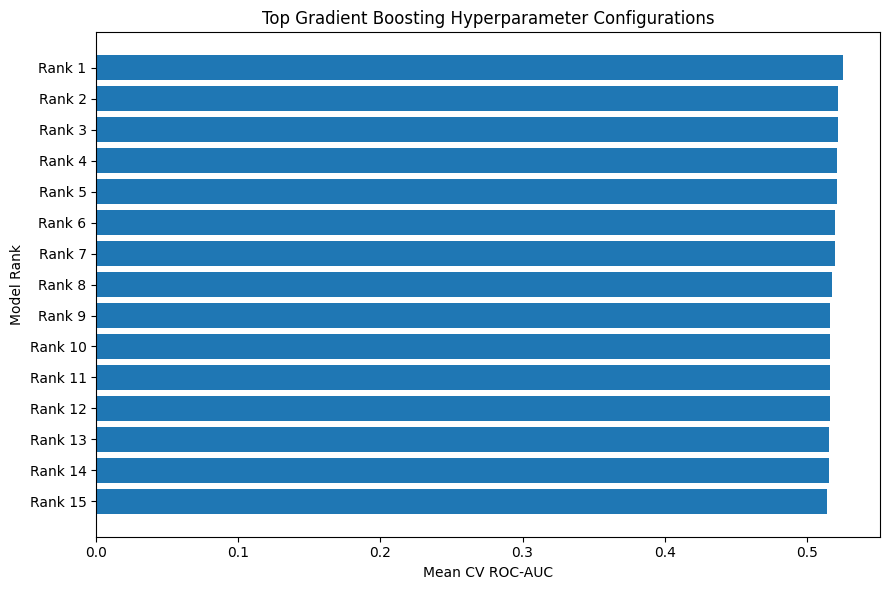

In [ ]:
# =========================
# Step 6: Plot top cross-validation results
# =========================

top_cv_results = cv_results_summary.head(15).copy()
top_cv_results = top_cv_results.sort_values("mean_test_score", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(range(len(top_cv_results)), top_cv_results["mean_test_score"])
plt.yticks(range(len(top_cv_results)), [f"Rank {r}" for r in top_cv_results["rank_test_score"]])
plt.xlabel("Mean CV ROC-AUC")
plt.ylabel("Model Rank")
plt.title("Top Gradient Boosting Hyperparameter Configurations")
plt.tight_layout()
plt.show()

## 6.5 Refit the Tuned Model

After hyperparameter tuning, the best Gradient Boosting configuration is refitted on the full training sample. The final out-of-sample test evaluation is postponed until Step 7.

In [ ]:
# =========================
# Step 6: Refit tuned model on full training sample
# =========================

best_gb_model.fit(X_train, y_train)

tuned_train_prob = best_gb_model.predict_proba(X_train)[:, 1]
tuned_train_pred = best_gb_model.predict(X_train)

tuned_train_auc = roc_auc_score(y_train, tuned_train_prob)
tuned_train_accuracy = accuracy_score(y_train, tuned_train_pred)
tuned_train_bal_accuracy = balanced_accuracy_score(y_train, tuned_train_pred)
tuned_train_f1 = f1_score(y_train, tuned_train_pred)

print("Tuned Gradient Boosting training metrics")
print("---------------------------------------")
print("Training ROC-AUC:", tuned_train_auc)
print("Training accuracy:", tuned_train_accuracy)
print("Training balanced accuracy:", tuned_train_bal_accuracy)
print("Training F1:", tuned_train_f1)

Tuned Gradient Boosting training metrics
---------------------------------------
Training ROC-AUC: 0.876356303710891
Training accuracy: 0.7948490230905861
Training balanced accuracy: 0.7929205134121172
Training F1: 0.8098765432098766


In [ ]:
# =========================
# Step 6: Modeling summary
# =========================

modeling_summary = pd.DataFrame({
    "model": [
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "training_roc_auc": [
        baseline_train_auc,
        tuned_train_auc
    ],
    "training_accuracy": [
        baseline_train_accuracy,
        tuned_train_accuracy
    ],
    "training_balanced_accuracy": [
        baseline_train_bal_accuracy,
        tuned_train_bal_accuracy
    ],
    "training_f1": [
        baseline_train_f1,
        tuned_train_f1
    ],
    "cv_roc_auc": [
        np.nan,
        best_cv_score
    ]
})

modeling_summary

,model,training_roc_auc,training_accuracy,training_balanced_accuracy,training_f1,cv_roc_auc
0,Baseline Gradient Boosting,0.866833,0.773535,0.770429,0.795181,NaN
1,Tuned Gradient Boosting,0.876356,0.794849,0.792921,0.809877,0.525325


In [ ]:
# =========================
# Step 6: Save model and modeling outputs
# =========================

MODEL_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_tuned_gradient_boosting_model.joblib")
BEST_PARAMS_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_best_gb_params.json")
CV_RESULTS_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_gb_cv_results.csv")
MODELING_SUMMARY_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_modeling_summary.csv")

joblib.dump(best_gb_model, MODEL_PATH)

with open(BEST_PARAMS_PATH, "w") as f:
    json.dump(best_params, f, indent=4)

cv_results_summary.to_csv(CV_RESULTS_PATH, index=False)
modeling_summary.to_csv(MODELING_SUMMARY_PATH, index=False)

print("Tuned model saved to:", MODEL_PATH)
print("Best parameters saved to:", BEST_PARAMS_PATH)
print("CV results saved to:", CV_RESULTS_PATH)
print("Modeling summary saved to:", MODELING_SUMMARY_PATH)

Tuned model saved to: /content/outputs/SPY_tuned_gradient_boosting_model.joblib
Best parameters saved to: /content/outputs/SPY_best_gb_params.json
CV results saved to: /content/outputs/SPY_gb_cv_results.csv
Modeling summary saved to: /content/outputs/SPY_modeling_summary.csv


## 6.6 Modeling Summary

A Gradient Boosting classifier is trained using the 17 final selected features. The model is first fitted with a baseline configuration and then tuned using randomized hyperparameter search with time-series cross-validation.

The hyperparameter search optimizes ROC-AUC on the training sample only. This preserves the final test set for out-of-sample evaluation and reduces the risk of overfitting to the test period.

The best tuned model uses the following hyperparameters:

- subsample: 0.6
- n_estimators: 300
- min_samples_leaf: 50
- max_features: None
- max_depth: 3
- learning_rate: 0.03

The tuned model achieves a cross-validated ROC-AUC of approximately 0.5253. This is only slightly above 0.5, suggesting that the selected technical features contain limited but non-zero predictive information in the training validation framework.

The training ROC-AUC is substantially higher than the cross-validation ROC-AUC, indicating potential overfitting and confirming the difficulty of short-term market direction prediction. The final out-of-sample test evaluation is therefore essential and is presented in the next section.

# Step 7: Evaluation

## 7.1 Evaluation Objective

This step evaluates the tuned Gradient Boosting classifier on the untouched out-of-sample test set. The test set was not used during feature selection, model training, or hyperparameter tuning.

The required evaluation metrics include:

- ROC-AUC;
- Confusion matrix;
- Classification report.

Additional supporting analysis includes comparison with a simple benchmark, feature importance review, and an optional signal-based backtest.

In [ ]:
# =========================
# Step 7: Import evaluation packages
# =========================

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [ ]:
# =========================
# Step 7: Load model and final modeling dataset
# =========================

FINAL_MODELING_DATA_PATH = os.path.join(DATA_DIR, f"{TICKER}_final_modeling_dataset.csv")
SELECTED_FEATURES_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_final_selected_features.json")
MODEL_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_tuned_gradient_boosting_model.joblib")

final_modeling_dataset = pd.read_csv(FINAL_MODELING_DATA_PATH, parse_dates=["Date"])

with open(SELECTED_FEATURES_PATH, "r") as f:
    final_selected_features = json.load(f)

best_gb_model = joblib.load(MODEL_PATH)

print("Final modeling dataset shape:", final_modeling_dataset.shape)
print("Number of selected features:", len(final_selected_features))
print("Loaded model:", best_gb_model)

Final modeling dataset shape: (1408, 20)
Number of selected features: 17
Loaded model: GradientBoostingClassifier(learning_rate=0.03, min_samples_leaf=50,
                           n_estimators=300, random_state=42, subsample=0.6)


In [ ]:
# =========================
# Step 7: Recreate chronological train-test split
# =========================

final_modeling_dataset = final_modeling_dataset.sort_values("Date").reset_index(drop=True)

split_idx = int(len(final_modeling_dataset) * TRAIN_RATIO)

train_data = final_modeling_dataset.iloc[:split_idx].copy()
test_data = final_modeling_dataset.iloc[split_idx:].copy()

X_train = train_data[final_selected_features].copy()
y_train = train_data["target"].copy()

X_test = test_data[final_selected_features].copy()
y_test = test_data["target"].copy()

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("Training period:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Test period:", test_data["Date"].min(), "to", test_data["Date"].max())

print("\nTest label distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training set shape: (1126, 17)
Test set shape: (282, 17)
Training period: 2020-05-26 00:00:00 to 2024-11-12 00:00:00
Test period: 2024-11-13 00:00:00 to 2025-12-30 00:00:00

Test label distribution:
target
1    150
0    132
Name: count, dtype: int64
target
1    0.531915
0    0.468085
Name: proportion, dtype: float64


## 7.2 Out-of-Sample Prediction

The tuned Gradient Boosting model produces predicted probabilities for the positive class. The default classification threshold is set to 0.5. A prediction is classified as an uptrend if the predicted probability is greater than or equal to 0.5.

In [ ]:
# =========================
# Step 7: Generate test predictions
# =========================

test_prob = best_gb_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

prediction_df = pd.DataFrame({
    "Date": test_data["Date"].values,
    "actual": y_test.values,
    "predicted": test_pred,
    "predicted_probability": test_prob,
    "forward_log_return": test_data["forward_log_return"].values
})

prediction_df.head()

,Date,actual,predicted,predicted_probability,forward_log_return
0,2024-11-13,0,1,0.623241,-0.006451
1,2024-11-14,0,1,0.616617,-0.012891
2,2024-11-15,1,0,0.475176,0.004089
3,2024-11-18,1,1,0.558304,0.003649
4,2024-11-19,0,1,0.540165,0.000339


In [ ]:
# =========================
# Step 7: Evaluation metrics
# =========================

test_roc_auc = roc_auc_score(y_test, test_prob)
test_accuracy = accuracy_score(y_test, test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)

evaluation_summary = pd.DataFrame({
    "metric": [
        "ROC-AUC",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "value": [
        test_roc_auc,
        test_accuracy,
        test_balanced_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

evaluation_summary

,metric,value
0,ROC-AUC,0.506414
1,Accuracy,0.510638
2,Balanced Accuracy,0.497273
3,Precision,0.530000
4,Recall,0.706667
5,F1-score,0.605714


## 7.3 Confusion Matrix

The confusion matrix summarizes the number of correct and incorrect predictions for each class. In this study:

- Class 0 represents a non-positive next-day market move;
- Class 1 represents a positive next-day market move.

In [ ]:
# =========================
# Step 7: Confusion matrix
# =========================

cm = confusion_matrix(y_test, test_pred)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

confusion_matrix_df

,Predicted 0,Predicted 1
Actual 0,38,94
Actual 1,44,106


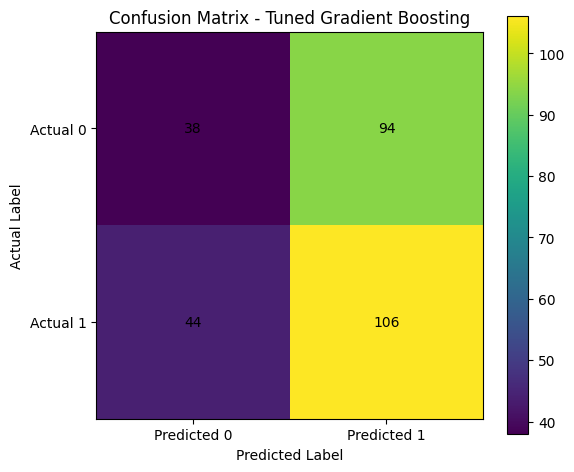

In [ ]:
# =========================
# Step 7: Plot confusion matrix
# =========================

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 7.4 Classification Report

The classification report provides class-specific precision, recall, and F1-score. This is useful because accuracy alone may be misleading if the model performs unevenly across the two classes.

In [ ]:
# =========================
# Step 7: Classification report
# =========================

classification_report_dict = classification_report(
    y_test,
    test_pred,
    target_names=["Class 0", "Class 1"],
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(classification_report_dict).T

classification_report_df

,precision,recall,f1-score,support
Class 0,0.463415,0.287879,0.355140,132.000000
Class 1,0.530000,0.706667,0.605714,150.000000
accuracy,0.510638,0.510638,0.510638,0.510638
macro avg,0.496707,0.497273,0.480427,282.000000
weighted avg,0.498832,0.510638,0.488424,282.000000


## 7.5 ROC Curve

ROC-AUC evaluates the model's ability to rank positive observations above negative observations across classification thresholds. A ROC-AUC of 0.5 indicates random ranking ability, while values above 0.5 suggest positive discriminatory power.

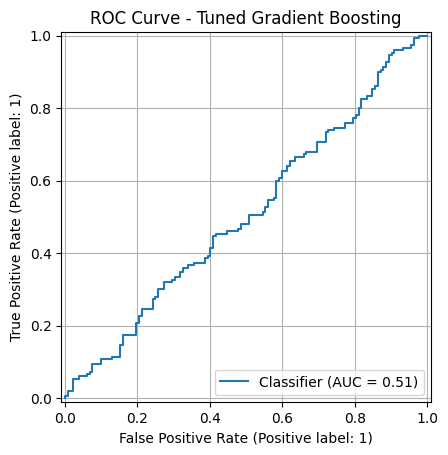

In [ ]:
# =========================
# Step 7: ROC curve
# =========================

RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title("ROC Curve - Tuned Gradient Boosting")
plt.grid(True)
plt.show()

## 7.6 Benchmark Comparison

A simple benchmark is included for comparison. The benchmark always predicts the majority class observed in the training sample. This provides a naive reference point for the tuned model.

In [ ]:
# =========================
# Step 7: Naive majority-class benchmark
# =========================

majority_class = y_train.value_counts().idxmax()

benchmark_pred = np.repeat(majority_class, len(y_test))
benchmark_prob = np.repeat(y_train.mean(), len(y_test))

benchmark_summary = pd.DataFrame({
    "model": [
        "Naive Majority-Class Benchmark",
        "Tuned Gradient Boosting"
    ],
    "roc_auc": [
        roc_auc_score(y_test, benchmark_prob),
        test_roc_auc
    ],
    "accuracy": [
        accuracy_score(y_test, benchmark_pred),
        test_accuracy
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(y_test, benchmark_pred),
        test_balanced_accuracy
    ],
    "precision": [
        precision_score(y_test, benchmark_pred, zero_division=0),
        test_precision
    ],
    "recall": [
        recall_score(y_test, benchmark_pred, zero_division=0),
        test_recall
    ],
    "f1_score": [
        f1_score(y_test, benchmark_pred, zero_division=0),
        test_f1
    ]
})

benchmark_summary

,model,roc_auc,accuracy,balanced_accuracy,precision,recall,f1_score
0,Naive Majority-Class Benchmark,0.500000,0.531915,0.500000,0.531915,1.000000,0.694444
1,Tuned Gradient Boosting,0.506414,0.510638,0.497273,0.530000,0.706667,0.605714


## 7.7 Feature Importance Review

The feature importance values from the tuned Gradient Boosting model are reviewed to understand which selected variables contribute most to the final classifier. These importances should be interpreted as model-based predictive importance, not as causal effects.

In [ ]:
# =========================
# Step 7: Final model feature importance
# =========================

final_feature_importance = pd.DataFrame({
    "feature": final_selected_features,
    "importance": best_gb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

final_feature_importance

,feature,importance
0,price_to_ma_50,0.077703
1,rolling_volatility_5,0.075123
2,rolling_kurt_60,0.073710
3,volume_ma_60,0.068109
4,volume_ma_5,0.065676
5,volume_change_ma_20,0.065191
6,log_return_lag_10,0.064637
7,close_to_low,0.061801
8,price_to_ma_10,0.060650
9,rolling_mean_return_20,0.057112


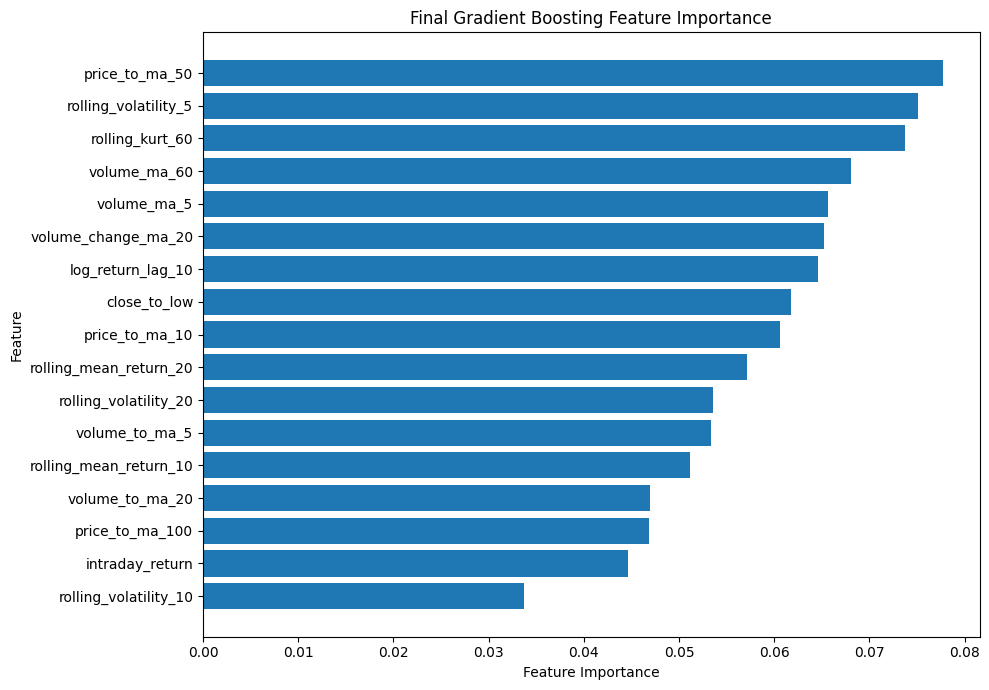

In [ ]:
# =========================
# Step 7: Plot final model feature importance
# =========================

plot_importance = final_feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Final Gradient Boosting Feature Importance")
plt.tight_layout()
plt.show()

## 7.8 Optional Signal-Based Backtest

As an optional extension, predicted labels are converted into a simple long-or-cash trading signal. If the model predicts class 1, the strategy holds SPY for the next trading day; otherwise, it stays in cash.

This is not a full production trading strategy. It is used only as an additional diagnostic to examine whether the classification signals have economic meaning.

In [ ]:
# =========================
# Step 7: Optional signal-based backtest
# =========================

backtest_df = prediction_df.copy()

# Long SPY if the model predicts a positive next-day move; otherwise stay in cash.
backtest_df["strategy_position"] = backtest_df["predicted"]

# The prediction made at time t is applied to the forward return r_{t+1}.
backtest_df["strategy_log_return"] = (
    backtest_df["strategy_position"] * backtest_df["forward_log_return"]
)

backtest_df["market_log_return"] = backtest_df["forward_log_return"]

backtest_df["strategy_cumulative_return"] = np.exp(backtest_df["strategy_log_return"].cumsum()) - 1
backtest_df["market_cumulative_return"] = np.exp(backtest_df["market_log_return"].cumsum()) - 1

backtest_df.head()

,Date,actual,predicted,predicted_probability,forward_log_return,strategy_position,strategy_log_return,market_log_return,strategy_cumulative_return,market_cumulative_return
0,2024-11-13,0,1,0.623241,-0.006451,1,-0.006451,-0.006451,-0.006430,-0.006430
1,2024-11-14,0,1,0.616617,-0.012891,1,-0.012891,-0.012891,-0.019156,-0.019156
2,2024-11-15,1,0,0.475176,0.004089,0,0.000000,0.004089,-0.019156,-0.015137
3,2024-11-18,1,1,0.558304,0.003649,1,0.003649,0.003649,-0.015571,-0.011537
4,2024-11-19,0,1,0.540165,0.000339,1,0.000339,0.000339,-0.015237,-0.011202


In [ ]:
# =========================
# Step 7: Backtest performance summary
# =========================

def annualized_sharpe(log_returns, periods_per_year=252):
    """Compute annualized Sharpe ratio using log returns."""
    if log_returns.std() == 0:
        return np.nan
    return (log_returns.mean() / log_returns.std()) * np.sqrt(periods_per_year)

strategy_total_return = backtest_df["strategy_cumulative_return"].iloc[-1]
market_total_return = backtest_df["market_cumulative_return"].iloc[-1]

strategy_sharpe = annualized_sharpe(backtest_df["strategy_log_return"])
market_sharpe = annualized_sharpe(backtest_df["market_log_return"])

strategy_hit_ratio = (
    np.sign(backtest_df["strategy_log_return"]) == np.sign(backtest_df["market_log_return"])
).mean()

backtest_summary = pd.DataFrame({
    "metric": [
        "Strategy Total Return",
        "Market Total Return",
        "Strategy Annualized Sharpe",
        "Market Annualized Sharpe",
        "Average Strategy Daily Return",
        "Average Market Daily Return"
    ],
    "value": [
        strategy_total_return,
        market_total_return,
        strategy_sharpe,
        market_sharpe,
        backtest_df["strategy_log_return"].mean(),
        backtest_df["market_log_return"].mean()
    ]
})

backtest_summary

,metric,value
0,Strategy Total Return,0.138715
1,Market Total Return,0.159179
2,Strategy Annualized Sharpe,0.662557
3,Market Annualized Sharpe,0.706041
4,Average Strategy Daily Return,0.000461
5,Average Market Daily Return,0.000524


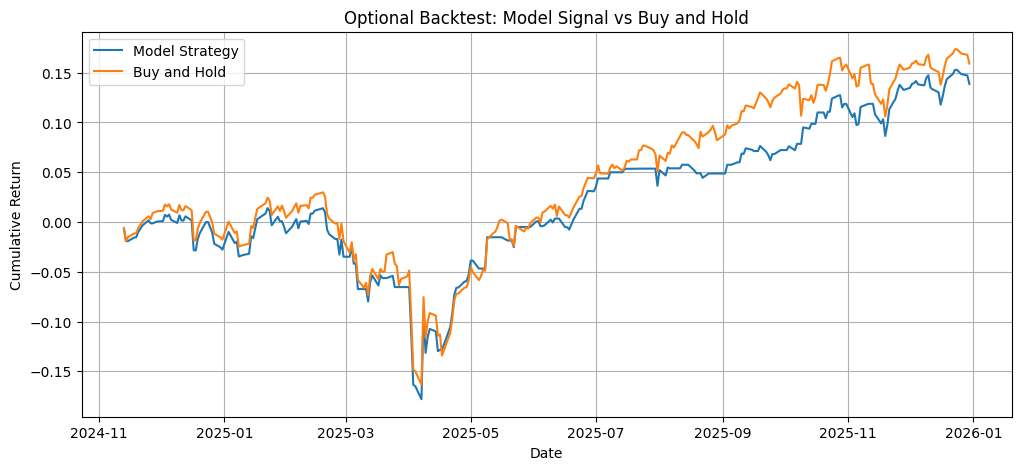

In [ ]:
# =========================
# Step 7: Plot cumulative returns
# =========================

plt.figure(figsize=(12, 5))
plt.plot(backtest_df["Date"], backtest_df["strategy_cumulative_return"], label="Model Strategy")
plt.plot(backtest_df["Date"], backtest_df["market_cumulative_return"], label="Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Optional Backtest: Model Signal vs Buy and Hold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================
# Step 7: Save evaluation outputs
# =========================

EVALUATION_SUMMARY_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_evaluation_summary.csv")
CONFUSION_MATRIX_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_confusion_matrix.csv")
CLASSIFICATION_REPORT_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_classification_report.csv")
BENCHMARK_SUMMARY_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_benchmark_summary.csv")
FINAL_IMPORTANCE_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_final_model_feature_importance.csv")
PREDICTIONS_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_test_predictions.csv")
BACKTEST_SUMMARY_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_backtest_summary.csv")
BACKTEST_DAILY_PATH = os.path.join(OUTPUT_DIR, f"{TICKER}_backtest_daily.csv")

evaluation_summary.to_csv(EVALUATION_SUMMARY_PATH, index=False)
confusion_matrix_df.to_csv(CONFUSION_MATRIX_PATH)
classification_report_df.to_csv(CLASSIFICATION_REPORT_PATH)
benchmark_summary.to_csv(BENCHMARK_SUMMARY_PATH, index=False)
final_feature_importance.to_csv(FINAL_IMPORTANCE_PATH, index=False)
prediction_df.to_csv(PREDICTIONS_PATH, index=False)
backtest_summary.to_csv(BACKTEST_SUMMARY_PATH, index=False)
backtest_df.to_csv(BACKTEST_DAILY_PATH, index=False)

print("Evaluation summary saved to:", EVALUATION_SUMMARY_PATH)
print("Confusion matrix saved to:", CONFUSION_MATRIX_PATH)
print("Classification report saved to:", CLASSIFICATION_REPORT_PATH)
print("Benchmark summary saved to:", BENCHMARK_SUMMARY_PATH)
print("Final feature importance saved to:", FINAL_IMPORTANCE_PATH)
print("Predictions saved to:", PREDICTIONS_PATH)
print("Backtest summary saved to:", BACKTEST_SUMMARY_PATH)
print("Backtest daily results saved to:", BACKTEST_DAILY_PATH)

Evaluation summary saved to: /content/outputs/SPY_evaluation_summary.csv
Confusion matrix saved to: /content/outputs/SPY_confusion_matrix.csv
Classification report saved to: /content/outputs/SPY_classification_report.csv
Benchmark summary saved to: /content/outputs/SPY_benchmark_summary.csv
Final feature importance saved to: /content/outputs/SPY_final_model_feature_importance.csv
Predictions saved to: /content/outputs/SPY_test_predictions.csv
Backtest summary saved to: /content/outputs/SPY_backtest_summary.csv
Backtest daily results saved to: /content/outputs/SPY_backtest_daily.csv


## 7.9 Evaluation Summary

The tuned Gradient Boosting classifier is evaluated on the untouched out-of-sample test set. The model achieves a test ROC-AUC of 0.5064, which is only marginally above the random benchmark level of 0.5. This indicates that the model has very weak ranking ability for identifying positive next-day SPY moves.

The overall accuracy is 0.5106 and the balanced accuracy is 0.4973. The balanced accuracy below 0.5 suggests that the model does not classify the two classes equally well. The confusion matrix shows that the model tends to predict the positive class more frequently. It correctly identifies 106 actual positive observations but only 38 actual non-positive observations.

The classification report confirms this imbalance. The recall for Class 1 is 0.7067, meaning that the model captures many positive days. However, the recall for Class 0 is only 0.2879, showing weak ability to identify non-positive days. Therefore, the model is biased toward predicting uptrends.

Compared with the naive majority-class benchmark, the tuned Gradient Boosting model has a slightly higher ROC-AUC but lower accuracy and F1-score. This suggests that the model may contain limited ranking information but does not provide a strong classification advantage at the default 0.5 threshold.

The optional signal-based backtest also does not outperform buy-and-hold. The model strategy produces a total return of approximately 13.87%, compared with approximately 15.92% for buy-and-hold. The strategy Sharpe ratio is also lower than the market Sharpe ratio.

Overall, the results confirm that short-term SPY direction is difficult to predict. The complete supervised learning pipeline is implemented successfully, but the selected technical features provide limited out-of-sample predictive power over the test period. The final conclusion is therefore conservative: the model demonstrates a valid machine learning workflow, but it does not produce robust evidence of economically meaningful predictability.

# Final Conclusion

This report implements a complete supervised machine learning workflow for predicting positive short-term market moves in SPY. The study begins with a clean OHLCV dataset from Yahoo Finance and constructs a broad set of 83 technical and market-based features. A funnel-style feature selection process combining filter, wrapper, and embedded methods reduces the feature universe to 17 final predictors.

The selected features are economically interpretable and mainly reflect volume dynamics, trend deviation, lagged returns, rolling volatility, and intraday price pressure. These features are then used to train and tune a Gradient Boosting classifier with time-series cross-validation.

Despite the complete workflow, the empirical results show that short-term SPY direction remains difficult to predict. The tuned model achieves a test ROC-AUC of only 0.5064 and does not materially outperform a naive majority-class benchmark. The optional trading signal also underperforms a buy-and-hold strategy.

The main lesson is that a rigorous machine learning process does not guarantee strong predictability in noisy financial markets. The result is consistent with the general difficulty of forecasting short-term asset returns. Future improvements could include richer predictors, alternative assets, different target definitions, transaction-cost-aware backtesting, and model ensemble methods.